In [1]:
##### PYTHON IMPORTS #####
import os
import time
import tempfile
from tempfile import NamedTemporaryFile
import gc
import logging
import itertools
import warnings
import csv
from configparser import ConfigParser
import psutil
import threading
import sys

from IPython.display import display, Javascript

##### NUMPY & PANDAS IMPORTS #####
import numpy as np
import pandas as pd
from pandas.errors import SettingWithCopyWarning

##### MATPLOTLIB IMPORTS #####
import matplotlib.pyplot as plt

##### RE, STRING & DEMOJI IMPORTS #####
import re
import string
import demoji
import emoji

##### NLTK IMPORTS #####
import nltk
from nltk.stem import SnowballStemmer
from nltk.stem.wordnet import WordNetLemmatizer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize

##### WORDCLOUD IMPORTS #####
from wordcloud import WordCloud

##### TQDM IMPORTS #####
from tqdm import tqdm

##### LANGDETECT IMPORTS #####
from langdetect import detect

##### LANGCODES IMPORTS #####
from langcodes import Language, LanguageTagError

##### DEEP_TRANSLATOR IMPORTS #####
from deep_translator import GoogleTranslator

##### SPACY IMPORTS #####
import spacy

##### PICKLE IMPORTS #####
import pickle

##### TORCH IMPORTS #####
import torch
from torch.utils.data import DataLoader, TensorDataset
from torch.nn import BCEWithLogitsLoss, BCELoss
from torch.optim import Adam
import torch.nn as nn
import torch.nn.functional as F
import torchtext.vocab as vocab

##### TRANSFORMERS IMPORTS #####
from transformers import (AutoTokenizer, AutoModel, pipeline,
                          DistilBertForSequenceClassification, DistilBertTokenizer, 
                          Seq2SeqTrainer, DataCollatorForSeq2Seq, AutoModelForSeq2SeqLM, 
                          AutoModelForSequenceClassification, Seq2SeqTrainingArguments,
                          TFAutoModelForSequenceClassification, AutoConfig)

from sentence_transformers import SentenceTransformer

##### HUGGINGFACE_HUB IMPORTS #####
from huggingface_hub import notebook_login

##### TENSORFLOW & KERAS IMPORTS #####
import tensorflow as tf
from keras.models import Sequential, Model
from keras.layers import (Dense, LSTM, Embedding, Input, concatenate, Flatten, Dropout, 
                          Conv1D, MaxPooling1D, GlobalMaxPooling1D, GlobalAveragePooling1D)

##### SKLEARN IMPORTS #####
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (classification_report, f1_score, roc_auc_score, 
                             accuracy_score, confusion_matrix, ConfusionMatrixDisplay)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.decomposition import PCA, IncrementalPCA
from sklearn.manifold import TSNE


##### IMBALANCE_LEARN IMPORTS #####
from imblearn.under_sampling import RandomUnderSampler

##### GENSIM IMPORTS #####
import gensim  
from gensim.models import Word2Vec
from gensim.models.callbacks import CallbackAny2Vec

##### SCIPY IMPORTS #####
from scipy.special import softmax

##### PLOTLY IMPORTS #####
import plotly.graph_objects as go

##### EVALUATE IMPORTS #####
import evaluate

##### CYTHON IMPORTS #####
import cython

##### SET SEEDS #####
tf.random.set_seed(42)
np.random.seed(42)
torch.manual_seed(42)
torch.cuda.manual_seed(42)

##### DEVICE SETUP #####
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

##### NLTK DOWNLOADS #####
#nltk.download("punkt")
#nltk.download("stopwords")
#nltk.download("wordnet")

In [2]:
os.getcwd()

'c:\\Users\\andre\\OneDrive\\Documentos\\Nova IMS\\1º ano\\2º Semestre\\Text Mining\\Project\\Repos\\NLP_AirBnB-Listings'

In [3]:
os.chdir("./data")

In [4]:
os.getcwd()

'c:\\Users\\andre\\OneDrive\\Documentos\\Nova IMS\\1º ano\\2º Semestre\\Text Mining\\Project\\Repos\\NLP_AirBnB-Listings\\data'

#### Auxiliary Functions

In [ ]:
# # Auxiliary function for confusion matrix plotting

# def plot_conf_matrix(y_true, y_pred, labels=["Not Unlisted", "Unlisted"], plot_name="Confusion Matrix"):
#     cm = confusion_matrix(y_true, y_pred)
#     disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
#     disp.plot(cmap=plt.cm.Blues)
#     plt.title(plot_name)
#     plt.show()

In [ ]:
# # Function to detect language of the comment

# def detect_and_return_language(text):
#     try:
#         detected_lang_code = detect(text)
#         lang = Language.get(detected_lang_code)
#         return lang.display_name().lower()
#     except ValueError:
#         raise ValueError("Language code not found")

In [ ]:
# # Function to check if any contraction exists in a text

# def contains_contractions(text, contractions_list):
#     for contraction in contractions_list:
#         if contraction in str(text):
#             return True
#     return False

# contractions_dict = {
#     "ain't": "am not",
#     "aren't": "are not",
#     "can't": "cannot",
#     "couldn't": "could not",
#     "didn't": "did not",
#     "doesn't": "does not",
#     "don't": "do not",
#     "hadn't": "had not",
#     "hasn't": "has not",
#     "haven't": "have not",
#     "he'd": "he would",
#     "he'll": "he will",
#     "he's": "he is",
#     "I'd": "I would",
#     "I'll": "I will",
#     "I'm": "I am",
#     "I've": "I have",
#     "isn't": "is not",
#     "it's": "it is",
#     "let's": "let us",
#     "mustn't": "must not",
#     "shan't": "shall not",
#     "she'd": "she would",
#     "she'll": "she will",
#     "she's": "she is",
#     "shouldn't": "should not",
#     "that's": "that is",
#     "there's": "there is",
#     "they'd": "they would",
#     "they'll": "they will",
#     "they're": "they are",
#     "they've": "they have",
#     "we'd": "we would",
#     "we'll": "we will",
#     "we're": "we are",
#     "we've": "we have",
#     "weren't": "were not",
#     "what'll": "what will",
#     "what're": "what are",
#     "what's": "what is",
#     "what've": "what have",
#     "where's": "where is",
#     "who'd": "who would",
#     "who'll": "who will",
#     "who're": "who are",
#     "who's": "who is",
#     "who've": "who have",
#     "won't": "will not",
#     "wouldn't": "would not",
#     "you'd": "you would",
#     "you'll": "you will",
#     "you're": "you are",
#     "you've": "you have",
#     }
# contractions_list = list(contractions_dict.keys())

# # Function to expand contractions
# def expand_contractions(text):
#     # Regular expression pattern to find contractions
#     contractions_pattern = re.compile(
#         "({})".format("|".join(contractions_dict.keys())),
#         flags=re.IGNORECASE | re.DOTALL,
#     )

#     def expand_match(contraction):
#         match = contraction.group(0)
#         first_char = match[0]
#         expanded_contraction = (
#             contractions_dict.get(match)
#             if contractions_dict.get(match)
#             else contractions_dict.get(match.lower())
#         )
#         if expanded_contraction is None:
#             expanded_contraction = match
#         else:
#             expanded_contraction = first_char + expanded_contraction[1:]
#         return expanded_contraction

#     # Replace contractions with their expanded forms
#     expanded_text = contractions_pattern.sub(expand_match, text)
#     return expanded_text

In [ ]:
# # EXTRA METHOD - CONVERTING EMOJIS TO TEXT

# def emoji_to_text(text):
#     """
#     Convert emojis to text
#     """

#     text = emoji.demojize(text)

#     # Replace underscores in emoji descriptions with spaces
#     text = re.sub(r'_', ' ', text)
    
#     # Insert spaces around the emoji text descriptions (delimited by colons)
#     text = re.sub(r'(:\S+?:)', r' \1 ', text)

#     # Remove multiple spaces if they occur
#     text = re.sub(r'\s+', ' ', text)

#     # Remove any spaces at beginning or end
#     return text.strip()

In [ ]:
# # Function to clean data
# # Using regex to remove html tags, money symbols, dates among others

# def clean_df(df):

#     copy_df = df.copy()
    

#     # to better visualise the following regular expressions please visit: https://extendsclass.com/regex-tester.html#python
#     html_tag_regex = r"<\W*[a-zA-Z]{1,8}\s*\W*>"

#     date_regex = r"\d{2}/\d{2}/(\d{4}|\d{2})|((\d{4}|\d{2})/\d{2}/\d{2})"

#     time_regex = (r"\b((\d{1,2}((?:h|H|:|-)\d{2}(min)?)(?:AM|PM)?)|(\d{1,2}\s*(?:AM|PM|h|H)))\b")

#     regex_for_monetary_values = r"^(\b((?:€|EUR|\$|USD|GBP|£|JPY|¥)\s*(?:\d+(?:\.\d{1,2})?|\.\d{1,2}))\b|\b((?:\d+(?:\.\d{1,2})?|\.\d{1,2})\s*(?:€|EUR|\$|USD|GBP|£|JPY|¥))\b)$"


#     col_index_dict = {}
#     # print column name and its index
#     for i, col in enumerate(copy_df.columns):
#         col_index_dict[col] = i


#     for i in tqdm(range(len(copy_df))):
#         comment_index = col_index_dict["comments"]
#         house_description_index = col_index_dict["description"]
#         host_about_index = col_index_dict["host_about"]


#         # get the text
#         comment = str(copy_df.iloc[i, comment_index])
#         house_descrp = str(copy_df.iloc[i, house_description_index])
#         host_about = str(copy_df.iloc[i, host_about_index])
        
#         # Check for Contractions
#         comment_contains_contraction_boolean = col_index_dict["comments_contains_contraction"]
#         house_description_contains_contraction_boolean = col_index_dict["description_contains_contraction"]
#         host_about_contains_contraction_boolean = col_index_dict["host_about_contains_contraction"]


#         # Turning emojis into text - EXTRA PREPROCESSING METHOD
#         comment = emoji_to_text(comment)
#         house_descrp = emoji_to_text(house_descrp)
#         host_about = emoji_to_text(host_about)

#         # remove html tags
#         comment = re.sub(html_tag_regex, " ", comment)
#         house_descrp = re.sub(html_tag_regex, " ", house_descrp)
#         host_about = re.sub(html_tag_regex, " ", host_about)

#         # remove monetary references
#         comment = re.sub(regex_for_monetary_values, "MONETARY_VALUE_STAMP", comment)
#         house_descrp = re.sub(regex_for_monetary_values, "MONETARY_VALUE_STAMP", house_descrp)
#         host_about = re.sub(regex_for_monetary_values, "MONETARY_VALUE_STAMP", host_about)

#         # Change dates to DATE
#         comment = re.sub(date_regex, "DATE_STAMP", comment)
#         house_descrp = re.sub(date_regex, "DATE_STAMP", house_descrp)
#         host_about = re.sub(date_regex, "DATE_STAMP", host_about)

#         # remove time references
#         comment = re.sub(time_regex, "TIME_STAMP", comment)
#         house_descrp = re.sub(time_regex, "TIME_STAMP", house_descrp)
#         host_about = re.sub(time_regex, "TIME_STAMP", host_about)

#         # remove punctuation
#         comment = re.sub(r'[^\w\s]', ' ', comment)
#         house_descrp = re.sub(r'[^\w\s]', ' ', house_descrp)
#         host_about = re.sub(r'[^\w\s]', ' ', host_about)

#         # lower case everything
#         comment = comment.lower()
#         house_descrp = house_descrp.lower()
#         host_about = host_about.lower()

#         # Check for Contractions and Expand them
#         if comment_contains_contraction_boolean:
#             comment = expand_contractions(comment)
#         if house_description_contains_contraction_boolean:
#             house_descrp = expand_contractions(house_descrp)
#         if host_about_contains_contraction_boolean:
#             host_about = expand_contractions(host_about)
        
#         # Check for 'x000d' in text and remove
#         if "x000d" in str(comment):
#             comment = comment.replace("x000d", "")
#         if "x000d" in str(house_descrp):
#             house_descrp = house_descrp.replace("x000d", "")
#         if "x000d" in str(host_about):
#             host_about = host_about.replace("x000d", "")

#         # tokenize
#         comment = word_tokenize(comment)
#         house_descrp = word_tokenize(house_descrp)
#         host_about = word_tokenize(host_about)

#         # remove stop words
#         stop = set(stopwords.words('english'))
#         comment = [word for word in comment if word not in stop]
#         house_descrp = [word for word in house_descrp if word not in stop]
#         host_about = [word for word in host_about if word not in stop]

#         # join back to string
#         comment = " ".join(comment)
#         house_descrp = " ".join(house_descrp)
#         host_about = " ".join(host_about)

#         # update dataframe
#         copy_df.iloc[i, col_index_dict["comments"]] = comment
        
#         copy_df.iloc[i, col_index_dict["description"]] = house_descrp

#         copy_df.iloc[i, col_index_dict["host_about"]] = host_about


#     # drop contain_contraction columns
#     if "comments_contains_contraction" in copy_df.columns:
#         copy_df.drop(columns=["comments_contains_contraction"], inplace=True)
#     if "description_contains_contraction" in copy_df.columns:
#         copy_df.drop(columns=["description_contains_contraction"], inplace=True)
#     if "host_about_contains_contraction" in copy_df.columns:
#         copy_df.drop(columns=["host_about_contains_contraction"], inplace=True)


#     return copy_df

In [ ]:
# # Function to merge all comments into same line for each property
# # This is done to have all comments in a single cell for each property

# def create_df_with_comments_and_target(df):
#     """
#     Converte os comentários de várias propriedades para uma única string, agrupando-os por listing_id.
#     Devolve um dataframe com os comentários agrupados na mesma célula e a variável target.
#     Args:
#         df (pd.Dataframe): dataframe com os comentários de várias propriedades e a variável target.

#     Returns:
#         pd.Dataframe: dataframe com os comentários agrupados na mesma célula e a variável target.
#     """
#     df2 = df.copy()
#     df2 = df2.groupby("listing_id").agg({"comments": ",".join, "unlisted": "first"}).reset_index()
#     # for every listing_id add host_about and description
#     df2["host_about"] = df2["listing_id"].apply(lambda x: df[df["listing_id"] == x]["host_about"].values[0])
#     df2["description"] = df2["listing_id"].apply(lambda x: df[df["listing_id"] == x]["description"].values[0])
#     return df2



# # Same function but for test data

# def create_df_with_comments(df):
#     """O mesmo que em cima, mas para o test que n tem target
#     PARA O DATASET DE PREDICTIONS!

#     Args:
#         df (pd.Dataframe): dataframe com os comentários de várias propriedades

#     Returns:
#         pd.Dataframe: dataframe com os comentários agrupados na mesma célula
#     """
#     df2 = df.copy()
#     df2 = df2.groupby("listing_id").agg({"comments": ",".join, }).reset_index()
#     # for every listing_id add host_about and description
#     df2["host_about"] = df2["listing_id"].apply(lambda x: df[df["listing_id"] == x]["host_about"].values[0])
#     df2["description"] = df2["listing_id"].apply(lambda x: df[df["listing_id"] == x]["description"].values[0])
#     return df2

In [ ]:
# #raw datasets
# raw_train = pd.read_csv("train.csv")
# raw_train_reviews = pd.read_csv("train_reviews.csv")

# Data Exploration - before preprocessing

In [ ]:
# raw_train.head(10)  

,index,description,host_about,unlisted
0,1,"This is a shared mixed room in our hostel, wit...",Alojamento Local Registro: 20835/AL,0
1,2,"O meu espaço fica perto de Parque Eduardo VII,...","I am friendly host, and I will try to always b...",1
2,3,Trafaria’s House is a cozy and familiar villa ...,"I am a social person liking to communicate, re...",1
3,4,"Apartamento Charmoso no Chiado, Entre o Largo ...",Hello!_x000D_\nI m Portuguese and i love to me...,0
4,5,Joli appartement en bordure de mer.<br /> 2 m...,Nous sommes une famille avec deux enfants de 1...,0
5,6,"IMPORTANT: In response to COVID-19, this prope...","Hi, we are Homing - a company that develops it...",0
6,7,This is my home that I rent out when I'm trave...,Globe trotter. I'm of Portuguese nationality w...,1
7,8,Find tranquility in this meticulously curated ...,I travel a lot and I love it. _x000D_\nOrigina...,0
8,9,Charming apartment with one bedroom with doubl...,"Isabel & Helder, portugueses, parents of three...",0
9,10,Walk up original wooden stairs to the entrance...,Serviced holiday apartments casa in Azenhas do...,0


In [ ]:
# raw_train_reviews.head(10)

,index,comments
0,1,this is a very cozy and comfortable house to s...
1,1,good<br/>
2,1,"My first hostel experience, and all I have to ..."
3,1,Das Hostel war neu und deshalb funktionierte a...
4,1,"It was fine for a dorm, but I think for the pe..."
5,1,Our stay in Lisbon Tip Hostel was very good. T...
6,1,Close to shops in town and a comfortable place...
7,1,Young and friendly staff. Great location along...
8,1,The place is just off the Parque metro stop wh...
9,1,Had a nice stay at this hostel. The beds were ...


In [ ]:
# raw_train_reviews.comments[0]

'this is a very cozy and comfortable house to stay in.never worry about the safety and the host is very nice.very close to parque metro station.easy to find.'

In [ ]:
# # Rename 'index' column to 'listing_id'
# raw_train_reviews.rename(columns={"index": "listing_id"}, inplace=True)
# raw_train.rename(columns={"index": "listing_id"}, inplace=True)

In [ ]:
# raw_train.shape

(6248, 4)

In [ ]:
# raw_train_reviews.shape

(361281, 2)

In [ ]:
# raw_train.isna().sum()

listing_id     0
description    0
host_about     0
unlisted       0
dtype: int64

In [ ]:
# raw_train_reviews.isna().sum()

listing_id    0
comments      2
dtype: int64

We need to drop NAs before converting column types otherwise they will stop being considered as NA and dropping will not work.<br>
We drop them bcause they are just 2. If they were many more we wouldn't drop them.

In [ ]:
# raw_train_reviews.dropna(subset=["comments"], inplace=True)

In [ ]:
# raw_train_reviews.isna().sum()

listing_id    0
comments      0
dtype: int64

In [ ]:
# listing_correct_types = {"description": str, "host_about": str}

# reviews_correct_types = {"comments": str}

# raw_train = raw_train.astype(listing_correct_types)
# raw_train_reviews = raw_train_reviews.astype(reviews_correct_types)

### Unlisted

In [ ]:
# raw_train["unlisted"].unique()

array([0, 1], dtype=int64)

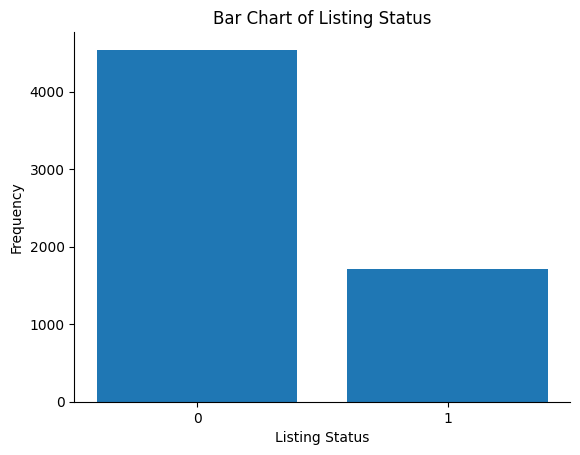

In [ ]:
# plt.bar(
#     raw_train["unlisted"].value_counts().index,
#     raw_train["unlisted"].value_counts().values,
# )
# plt.grid(False)
# plt.title("Bar Chart of Listing Status")
# plt.xlabel("Listing Status")
# plt.ylabel("Frequency")
# plt.xticks(np.arange(0,2))
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.show()

### Description

In [ ]:
# # Get size of description and order by biggest to smallest
# raw_train["description"].apply(len).value_counts()

description
1000    3769
35        37
33        21
36        16
547       14
        ... 
143        1
68         1
977        1
696        1
695        1
Name: count, Length: 851, dtype: int64

In [ ]:
# # Get word count of description and order by biggest to smallest
# raw_train["description_word_count"] = raw_train["description"].apply(lambda x: len(str(x).split(" ")))

# raw_train["description_word_count"].value_counts()

description_word_count
166    184
165    176
164    172
162    163
163    162
      ... 
204      1
205      1
210      1
197      1
195      1
Name: count, Length: 198, dtype: int64

In [ ]:
# raw_train[raw_train["description_word_count"] == 3]["description"]

281      <b>License number</b><br />43084/AL
653      <b>License number</b><br />37710/AL
713      <b>License number</b><br />92019/AL
746        <b>License number</b><br />Exempt
899       <b>License number</b><br />6005/al
                        ...                 
5769     <b>License number</b><br />45360/AL
5869     <b>License number</b><br />60911/AL
5965     <b>License number</b><br />48184/AL
6068    <b>License number</b><br />123056/AL
6245       <b>License number</b><br />Exempt
Name: description, Length: 89, dtype: object

In [ ]:
# raw_train["description_word_count"].describe()

count    6248.000000
mean      132.860755
std        48.084904
min         3.000000
25%        99.000000
50%       157.000000
75%       167.000000
max       210.000000
Name: description_word_count, dtype: float64

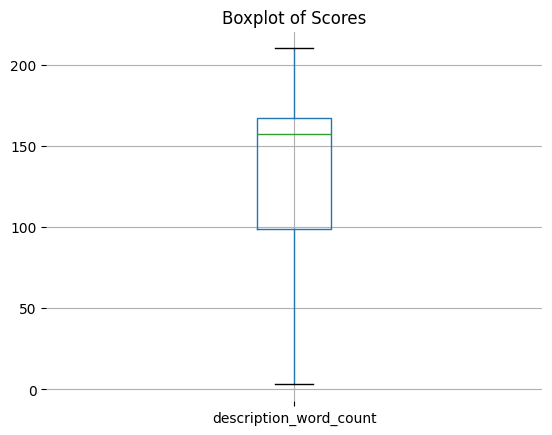

In [ ]:
# raw_train.boxplot(column=["description_word_count"])
# plt.title("Boxplot of Scores")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.gca().spines["bottom"].set_visible(False)
# plt.gca().spines["left"].set_visible(False)
# plt.show()

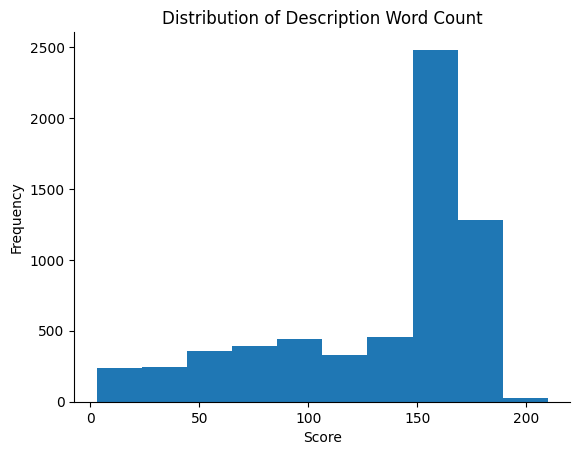

In [ ]:
# raw_train["description_word_count"].hist()
# plt.grid(False)
# plt.title("Distribution of Description Word Count")
# plt.xlabel("Score")
# plt.ylabel("Frequency")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.show()

In [ ]:
# all_words = " ".join(raw_train["description"].str.lower()).split()

# freq = pd.Series(all_words).value_counts()

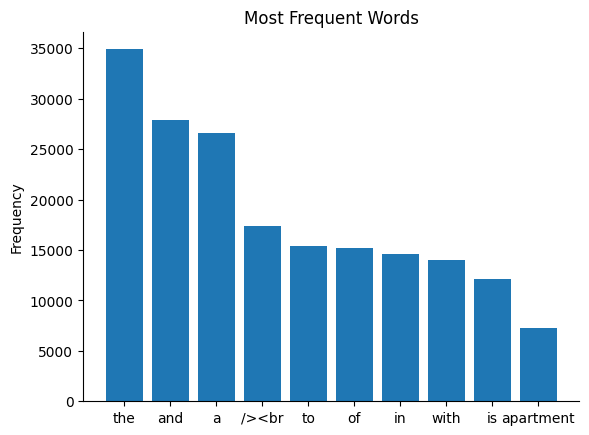

In [ ]:
# x_labels = freq.index[0:10]
# values = freq[:10]
# plt.bar(x_labels, values)
# plt.xticks(x_labels)
# plt.ylabel("Frequency")
# plt.title("Most Frequent Words")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.show()

### Comments

In [ ]:
# comment_counts = raw_train_reviews.groupby("listing_id")["comments"].count()

# # Sort the counts in descending order
# sorted_comment_counts = comment_counts.sort_values(ascending=False)

# # Display the top 10 indices with the most comments
# top_10_indices = sorted_comment_counts.head(10)
# top_10_indices

listing_id
265     891
3396    765
1147    678
4106    617
954     583
3729    578
1246    576
5833    571
5532    559
3085    552
Name: comments, dtype: int64

In [ ]:
# # get character count of comments
# raw_train_reviews["comment_character_count"] = raw_train_reviews["comments"].apply(len)
# raw_train_reviews["comment_character_count"].value_counts()

comment_character_count
88      1334
87      1164
89      1055
83      1040
82      1031
        ... 
2171       1
2984       1
2821       1
3746       1
2034       1
Name: count, Length: 2489, dtype: int64

In [ ]:
# # from 3 characters onwards, the comments seem to be valid
# raw_train_reviews[raw_train_reviews["comment_character_count"] == 3]["comments"].value_counts()

comments
Top    56
...    17
top    14
Bom    13
:-)     7
       ..
5*!     1
ooo     1
  C     1
non     1
Nan     1
Name: count, Length: 68, dtype: int64

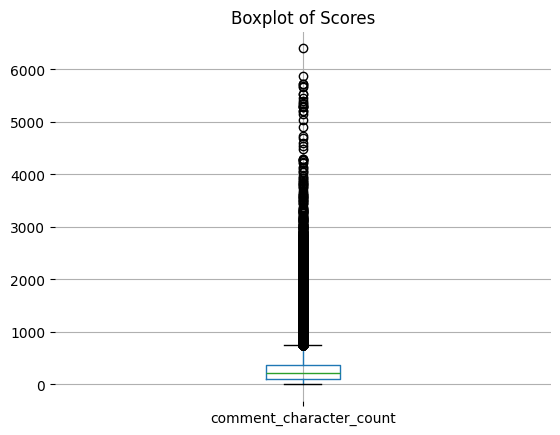

In [ ]:
# raw_train_reviews.boxplot(column=["comment_character_count"])
# plt.title("Boxplot of Scores")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.gca().spines["bottom"].set_visible(False)
# plt.gca().spines["left"].set_visible(False)
# plt.show()

In [ ]:
# freq = pd.Series(raw_train_reviews[raw_train_reviews["comment_character_count"] == 1]["comments"].value_counts())

c:\Users\andre\Desktop\Programação\nlp_env\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
c:\Users\andre\Desktop\Programação\nlp_env\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 128076 (\N{OK HAND SIGN}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


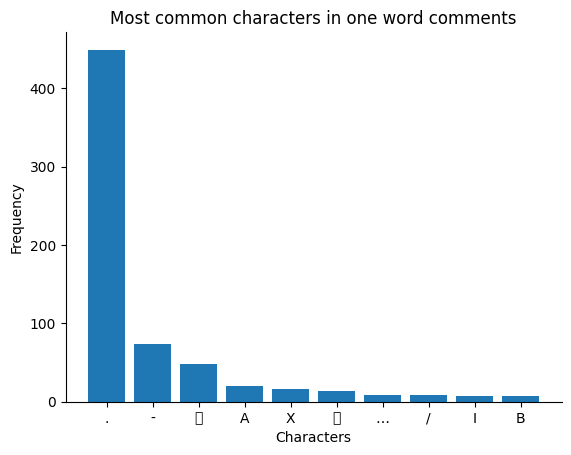

In [ ]:
# plt.bar(freq.index[:10], freq[:10])
# plt.grid(False)
# plt.title("Most common characters in one word comments")
# plt.xlabel("Characters")
# plt.ylabel("Frequency")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.show();

In [ ]:
# # get word count of comments
# raw_train_reviews["comment_word_count"] = raw_train_reviews["comments"].apply(lambda x: len(str(x).split(" ")))
# raw_train_reviews["comment_word_count"].value_counts()

comment_word_count
14     6232
13     5793
9      5691
11     5687
10     5627
       ... 
552       1
939       1
627       1
580       1
784       1
Name: count, Length: 595, dtype: int64

In [ ]:
# # Even 1-worded comments seem valid (apart from non-alphabetical ones, obviously)
# raw_train_reviews[raw_train_reviews["comment_word_count"] == 1]["comments"][:10]

1                                              good<br/>
39                                                   top
65                                            Recomendo.
145    房东非常体贴，而且房东的设计也非常好，我们非常喜欢他的地点，而且回答得很及时。<br/>我会...
159                               交通方便<br/>地方整潔<br/>有乾衣機
275                                                    .
317                                                    I
432                                                    👍
580                                                 Good
682                                                    .
Name: comments, dtype: object

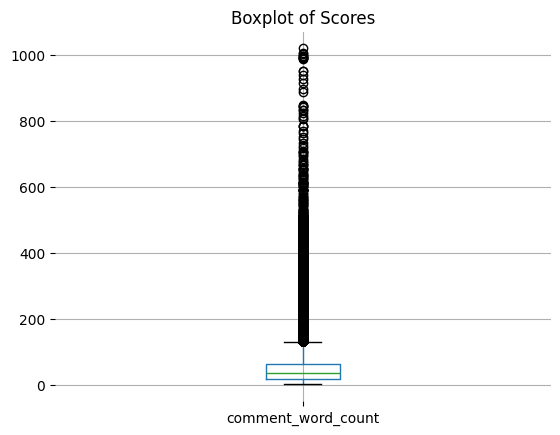

In [ ]:
# raw_train_reviews.boxplot(column=["comment_word_count"])
# plt.title("Boxplot of Scores")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.gca().spines["bottom"].set_visible(False)
# plt.gca().spines["left"].set_visible(False)
# plt.show()

In [ ]:
# all_comment_words = " ".join(raw_train_reviews["comments"].str.lower()).split()

# freq = pd.Series(all_comment_words).value_counts().sort_values(ascending=False)

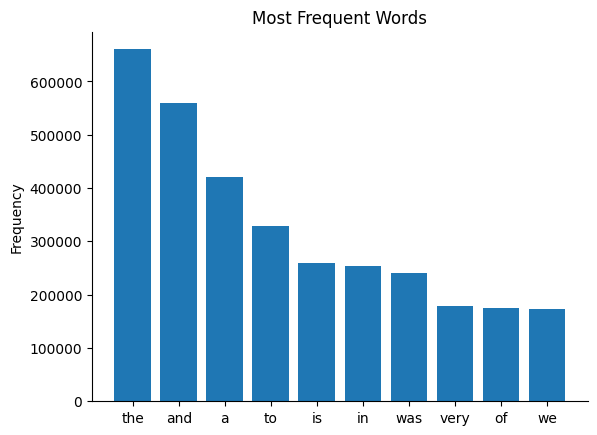

In [ ]:
# x_labels = freq.index[0:10]
# values = freq[:10]
# plt.bar(x_labels, values)
# plt.xticks(x_labels)
# plt.ylabel("Frequency")
# plt.title("Most Frequent Words")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.show()

In [ ]:
# # check for duplicates by 'listing_id' and 'comments', and show rows
# duplicated_rows = raw_train_reviews[raw_train_reviews.duplicated(["listing_id", "comments"])]

# duplicated_rows[["listing_id", "comments", "comment_word_count"]].sort_values("comment_word_count", ascending=False)[:10]

,listing_id,comments,comment_word_count
58173,987,Leider hat uns eine Coronainfektion während de...,184
36950,651,"Pas d'eau chaude pendant 4jours, on nous suggè...",109
232323,3959,Lincoln and Cameron’s flat is true gem. It’s l...,103
171194,2886,João Cunha é simplesmente um anfitrião super a...,98
13421,265,Maria and João were incredible; it was the bes...,89
48170,842,We LOVED staying here! We stayed here already ...,78
84893,1423,"Cozy, comfortable, good value apartment in a l...",49
49932,876,Had an excellent experience at hugo's apartmen...,48
216177,3674,Love the apartment ，cozy tidy and stylish. The...,47
346227,5969,"Nice, clean room in an apartment shared with o...",44


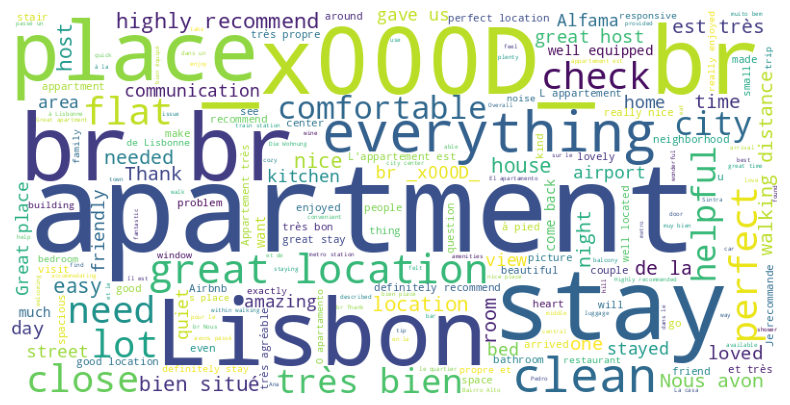

In [ ]:
# # Joining all the comments into a single string
# all_reviews = " ".join(raw_train_reviews["comments"])

# # Create WordCloud object
# wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_reviews)

# # Plotting the word cloud
# plt.figure(figsize=(10, 5))
# plt.imshow(wordcloud)
# plt.axis("off")
# plt.show();

### Host_about

In [ ]:
# # get size of host_about
# raw_train["host_about_character_count"] = raw_train["host_about"].apply(len)
# raw_train["host_about_character_count"].value_counts()

host_about_character_count
706     153
673      98
842      68
434      66
266      49
       ... 
1389      1
566       1
409       1
1735      1
817       1
Name: count, Length: 919, dtype: int64

In [ ]:
# raw_train[raw_train["host_about_character_count"] == 6]["host_about"]

476     Dalma 
514     Alfama
2287    Lisboa
2481    Alfama
2887    Canada
2987    LUGANO
5421    morena
Name: host_about, dtype: object

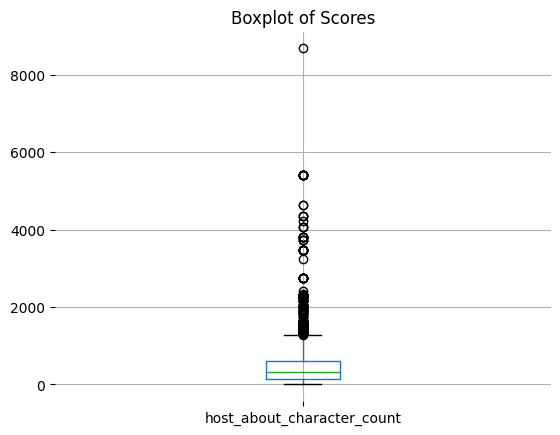

In [ ]:
# raw_train.boxplot(column=["host_about_character_count"])
# plt.title("Boxplot of Scores")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.gca().spines["bottom"].set_visible(False)
# plt.gca().spines["left"].set_visible(False)
# plt.show()

We decided not to show a bar plot of the `host_about_character_count` as there are many outliers (as seen above) and it would make the plot unreadable.

In [ ]:
# raw_train["host_about_word_count"] = raw_train["host_about"].apply(lambda x: len(str(x).split(" ")))

# raw_train["host_about_word_count"].value_counts()

host_about_word_count
110    157
1      138
108    105
2      103
43      98
      ... 
231      1
161      1
330      1
281      1
241      1
Name: count, Length: 264, dtype: int64

In [ ]:
# # It's ok to say even from 1-worded host_about, it's still valid (apart from non-alphabetical ones, obviously)
# raw_train[raw_train["host_about_word_count"] == 1]["host_about"]

85                           \n\n
92                              .
110                     _x000D_\n
193                    @ZMPoppe\n
351                         自驾游晚期
                  ...            
5965                          sss
5983                          sss
6048    Sports&NightLife_x000D_\n
6191              Perfeccionista.
6234                    Ruan&Chen
Name: host_about, Length: 138, dtype: object

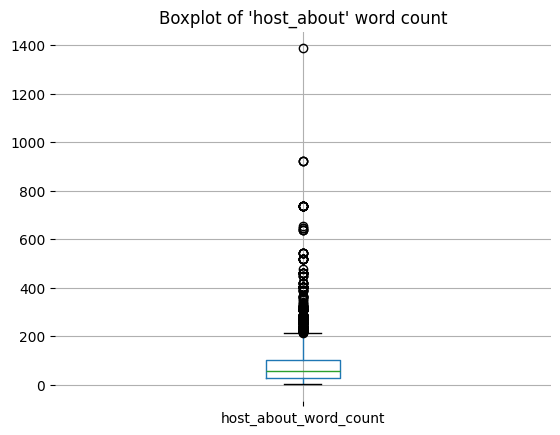

In [ ]:
# raw_train.boxplot(column=["host_about_word_count"])
# plt.title("Boxplot of 'host_about' word count")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.gca().spines["bottom"].set_visible(False)
# plt.gca().spines["left"].set_visible(False)
# plt.show()

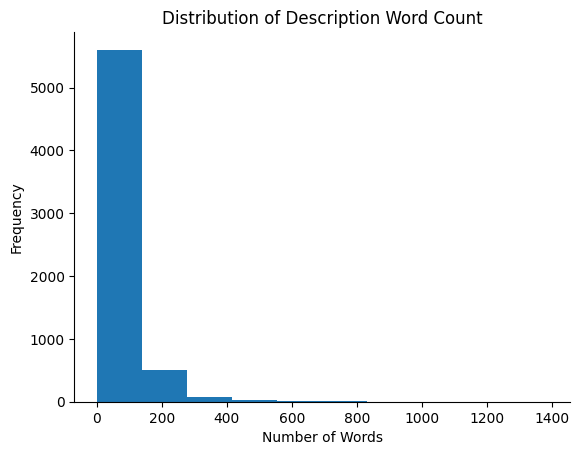

In [ ]:
# raw_train["host_about_word_count"].hist()
# plt.grid(False)
# plt.title("Distribution of Description Word Count")
# plt.xlabel("Number of Words")
# plt.ylabel("Frequency")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.show()

In [ ]:
# all_words = " ".join(raw_train["host_about"].str.lower()).split()

# freq = pd.Series(all_words).value_counts()

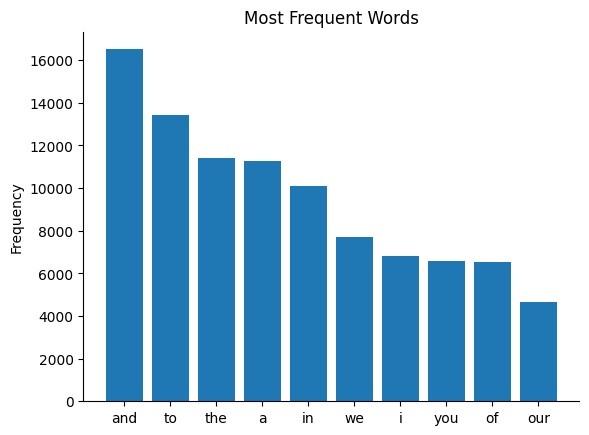

In [ ]:
# x_labels = freq.index[0:10]
# values = freq[:10]
# plt.bar(x_labels, values)
# plt.xticks(x_labels)
# plt.ylabel("Frequency")
# plt.title("Most Frequent Words")
# plt.gca().spines["top"].set_visible(False)
# plt.gca().spines["right"].set_visible(False)
# plt.show()

##### We're going to check how many comments from each language we have

In [ ]:
# def detect_language(text):
#     try:
#         return detect(text)
#     except:
#         return 'Error'  # In case text is too short or any other issue

In [ ]:
# # Apply the language detection to the 'comment' column
# tqdm.pandas()

# raw_train_reviews["language"] = raw_train_reviews["comments"].progress_apply(detect_language)

# raw_train_reviews.to_csv("train_reviews_with_langs.csv", index = False)

100%|██████████| 361279/361279 [22:42<00:00, 265.21it/s]


In [ ]:
# # Count the number of comments in each language
# raw_train_reviews = pd.read_csv("train_reviews_with_langs.csv")

# language_counts = raw_train_reviews["language"].value_counts()

# print(language_counts)

language
en       232333
fr        53280
pt        22455
es        19216
de        14209
it         5683
nl         3578
ru         1499
ko         1465
zh-cn      1038
Error       918
ro          812
pl          599
ca          576
da          461
sv          372
af          346
no          311
so          279
cs          206
fi          202
id          169
tl          155
hu          134
ja          108
cy          105
zh-tw        93
he           90
hr           76
sw           75
sk           72
tr           66
lt           57
el           49
uk           45
vi           44
sl           39
et           20
bg           15
ar            9
lv            9
sq            8
mk            2
ur            1
Name: count, dtype: int64


# Data Preprocessing

#### Note - **EXTRA METHODS**: Translation to English, Emoji to Text Conversion

First, we translated all non-english `description` and `host about` to english on the `train.xlsx` file. We also translated to english the `comments` on the `train_reviews.xlsx` file. We applied the exact same procedure for the `test.xlsx` and `test_reviews.xlsx`, since they follow the same structure.

-- TO-DO: Use only `raw_train_reviews` and subset comments that are not in english for translation process

#### Translation 


In [58]:
warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)

In [ ]:
# train= pd.read_csv("train.csv")
# train_reviews = pd.read_csv("train_reviews.csv")
# test = pd.read_csv("test.csv")
# test_reviews = pd.read_csv("test_reviews.csv")

Basic curation of rows with empty values

In [ ]:
# train.isna().sum()

index          0
description    0
host_about     0
unlisted       0
dtype: int64

In [ ]:
# train_reviews.isna().sum()

index       0
comments    2
dtype: int64

In [ ]:
# train_reviews.dropna(subset = "comments", inplace = True) # Just 2 comments were dropped, not worrisome
# train_reviews.reset_index(inplace = True, drop = True)

In [ ]:
# train_reviews.isna().sum()

index       0
comments    0
dtype: int64

In [ ]:
# test.isna().sum()

index          0
description    0
host_about     0
dtype: int64

In [ ]:
# test_reviews.isna().sum()

index       0
comments    0
dtype: int64

In [ ]:
# train.head(10)

,index,description,host_about,unlisted
0,1,"This is a shared mixed room in our hostel, wit...",Alojamento Local Registro: 20835/AL,0
1,2,"O meu espaço fica perto de Parque Eduardo VII,...","I am friendly host, and I will try to always b...",1
2,3,Trafaria’s House is a cozy and familiar villa ...,"I am a social person liking to communicate, re...",1
3,4,"Apartamento Charmoso no Chiado, Entre o Largo ...",Hello!_x000D_\nI m Portuguese and i love to me...,0
4,5,Joli appartement en bordure de mer.<br /> 2 m...,Nous sommes une famille avec deux enfants de 1...,0
5,6,"IMPORTANT: In response to COVID-19, this prope...","Hi, we are Homing - a company that develops it...",0
6,7,This is my home that I rent out when I'm trave...,Globe trotter. I'm of Portuguese nationality w...,1
7,8,Find tranquility in this meticulously curated ...,I travel a lot and I love it. _x000D_\nOrigina...,0
8,9,Charming apartment with one bedroom with doubl...,"Isabel & Helder, portugueses, parents of three...",0
9,10,Walk up original wooden stairs to the entrance...,Serviced holiday apartments casa in Azenhas do...,0


In [ ]:
# # Apply the language detection to the 'comment' column
# tqdm.pandas()

# train["language_description"] = train["description"].progress_apply(detect_language)
# train["language_host_about"] = train["host_about"].progress_apply(detect_language)

100%|██████████| 6248/6248 [00:30<00:00, 206.12it/s]


In [ ]:
# train.head(5)

,index,description,host_about,unlisted,language_description,language_host_about
0,1,"This is a shared mixed room in our hostel, wit...",Alojamento Local Registro: 20835/AL,0,en,pt
1,2,"O meu espaço fica perto de Parque Eduardo VII,...","I am friendly host, and I will try to always b...",1,pt,en
2,3,Trafaria’s House is a cozy and familiar villa ...,"I am a social person liking to communicate, re...",1,en,en
3,4,"Apartamento Charmoso no Chiado, Entre o Largo ...",Hello!_x000D_\nI m Portuguese and i love to me...,0,pt,en
4,5,Joli appartement en bordure de mer.<br /> 2 m...,Nous sommes une famille avec deux enfants de 1...,0,fr,fr


In [ ]:
# train.to_csv("train_with_langs.csv", index = False)

`train` Translation

In [ ]:
# error = 0

# train["description_en"] = np.nan
# train["host_about_en"] = np.nan

# columns = ["index", "description", "description_en", "host_about","host_about_en", "unlisted", "language_description", "language_host_about"]

# train = train[columns]

In [ ]:
# train.head()

,index,description,description_en,host_about,host_about_en,unlisted,language_description,language_host_about
0,1,"This is a shared mixed room in our hostel, wit...",NaN,Alojamento Local Registro: 20835/AL,NaN,0,en,pt
1,2,"O meu espaço fica perto de Parque Eduardo VII,...",NaN,"I am friendly host, and I will try to always b...",NaN,1,pt,en
2,3,Trafaria’s House is a cozy and familiar villa ...,NaN,"I am a social person liking to communicate, re...",NaN,1,en,en
3,4,"Apartamento Charmoso no Chiado, Entre o Largo ...",NaN,Hello!_x000D_\nI m Portuguese and i love to me...,NaN,0,pt,en
4,5,Joli appartement en bordure de mer.<br /> 2 m...,NaN,Nous sommes une famille avec deux enfants de 1...,NaN,0,fr,fr


In [ ]:
# for i in tqdm(range(len(train))):
#     # Check if the language is not English
#     if (train["language_description"][i] != "en" or train["language_host_about"][i] != "en"):
#         # If not English, attempt to translate
#         try:
#             # Attempt to translate the comment
#             train["description_en"][i] = GoogleTranslator(source='auto', target='en').translate(text=train["description"][i])
#             train["host_about_en"][i] = GoogleTranslator(source='auto', target='en').translate(text=train["host_about"][i])
#         except Exception as e:
#             # Log or handle translation errors
#             error += 1
#             train['description_en'][i]= train["description"][i]
#             train["host_about_en"][i] = train["host_about"][i]
            
#             print(f"Translation failed at index {i}: {e}")
#     else:
#         # If the language is already English, just copy the text
#         train["description_en"][i] = train["description"][i]
#         train["host_about_en"][i] = train["host_about"][i]
    

# print(f"Translation ended with {error} errors.")

  0%|          | 0/6248 [00:00<?, ?it/s]C:\Users\andre\AppData\Local\Temp\ipykernel_1152\2199921018.py:7: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  train["description_en"][i] = GoogleTranslator(source='auto', target='en').translate(text=

Translation failed at index 362: DE
Mit Bookiply finden Sie ganz einfach Ihre perfekte Ferienunterkunft. Eine schöne Villa mit Bergblick an der Algarve? Ein gemütliches Apartment im Herzen von Albufeira oder ein Strandhaus an der goldenen Küste? Um Ihnen einen erholsamen Aufenthalt in den schönsten Regionen Portugals zu bieten, konzentrieren wir uns auf die Zusammenarbeit mit geprüften Gastgebern, deren Unterkünfte unseren hohen Qualitätskriterien entsprechen. Neben dem Fokus auf die Qualität, bieten wir einen Kundenservice, der Sie schnell und unkompliziert bei allen Fragen und Anliegen an sieben Tagen die Woche unterstützt.
************************************************************************

EN
With Bookiply you can easily find your perfect vacation rental. A beautiful villa with mountain views in the Algarve? A cozy apartment in the heart of Albufeira or a beach house by the golden coastline? To offer you a relaxing stay in Portugal’s most beautiful regions, we focus on working

 14%|█▍        | 903/6248 [02:45<18:03,  4.93it/s]

Translation failed at index 902: DE
Mit Bookiply finden Sie ganz einfach Ihre perfekte Ferienunterkunft. Eine schöne Villa mit Bergblick an der Algarve? Ein gemütliches Apartment im Herzen von Albufeira oder ein Strandhaus an der goldenen Küste? Um Ihnen einen erholsamen Aufenthalt in den schönsten Regionen Portugals zu bieten, konzentrieren wir uns auf die Zusammenarbeit mit geprüften Gastgebern, deren Unterkünfte unseren hohen Qualitätskriterien entsprechen. Neben dem Fokus auf die Qualität, bieten wir einen Kundenservice, der Sie schnell und unkompliziert bei allen Fragen und Anliegen an sieben Tagen die Woche unterstützt.
************************************************************************

EN
With Bookiply you can easily find your perfect vacation rental. A beautiful villa with mountain views in the Algarve? A cozy apartment in the heart of Albufeira or a beach house by the golden coastline? To offer you a relaxing stay in Portugal’s most beautiful regions, we focus on working

 17%|█▋        | 1086/6248 [03:19<12:53,  6.68it/s]

...

Translation failed at index 5174: DE
Mit Bookiply finden Sie ganz einfach Ihre perfekte Ferienunterkunft. Eine schöne Villa mit Bergblick an der Algarve? Ein gemütliches Apartment im Herzen von Albufeira oder ein Strandhaus an der goldenen Küste? Um Ihnen einen erholsamen Aufenthalt in den schönsten Regionen Portugals zu bieten, konzentrieren wir uns auf die Zusammenarbeit mit geprüften Gastgebern, deren Unterkünfte unseren hohen Qualitätskriterien entsprechen. Neben dem Fokus auf die Qualität, bieten wir einen Kundenservice, der Sie schnell und unkompliziert bei allen Fragen und Anliegen an sieben Tagen die Woche unterstützt.
************************************************************************

EN
With Bookiply you can easily find your perfect vacation rental. A beautiful villa with mountain views in the Algarve? A cozy apartment in the heart of Albufeira or a beach house by the golden coastline? To offer you a relaxing stay in Portugal’s most beautiful regions, we focus on workin

 95%|█████████▍| 5934/6248 [20:37<01:03,  4.97it/s]

Translation failed at index 5933: DE
Mit Bookiply finden Sie ganz einfach Ihre perfekte Ferienunterkunft. Eine schöne Villa mit Bergblick an der Algarve? Ein gemütliches Apartment im Herzen von Albufeira oder ein Strandhaus an der goldenen Küste? Um Ihnen einen erholsamen Aufenthalt in den schönsten Regionen Portugals zu bieten, konzentrieren wir uns auf die Zusammenarbeit mit geprüften Gastgebern, deren Unterkünfte unseren hohen Qualitätskriterien entsprechen. Neben dem Fokus auf die Qualität, bieten wir einen Kundenservice, der Sie schnell und unkompliziert bei allen Fragen und Anliegen an sieben Tagen die Woche unterstützt.
************************************************************************

EN
With Bookiply you can easily find your perfect vacation rental. A beautiful villa with mountain views in the Algarve? A cozy apartment in the heart of Albufeira or a beach house by the golden coastline? To offer you a relaxing stay in Portugal’s most beautiful regions, we focus on workin

100%|██████████| 6248/6248 [21:28<00:00,  4.85it/s]

Translation ended with 13 errors.


In [ ]:
# train.to_csv("train_en.csv", index = False)

In [ ]:
# train.head()

,index,description,description_en,host_about,host_about_en,unlisted,language_description,language_host_about
0,1,"This is a shared mixed room in our hostel, wit...","This is a shared mixed room in our hostel, wit...",Alojamento Local Registro: 20835/AL,Local Accommodation Registration: 20835/AL,0,en,pt
1,2,"O meu espaço fica perto de Parque Eduardo VII,...","My space is close to Parque Eduardo VII, Salda...","I am friendly host, and I will try to always b...","I am friendly host, and I will try to always b...",1,pt,en
2,3,Trafaria’s House is a cozy and familiar villa ...,Trafaria’s House is a cozy and familiar villa ...,"I am a social person liking to communicate, re...","I am a social person liking to communicate, re...",1,en,en
3,4,"Apartamento Charmoso no Chiado, Entre o Largo ...","Charming apartment in Chiado, between Largo do...",Hello!_x000D_\nI m Portuguese and i love to me...,Hello!_x000D_\nI m Portuguese and i love to me...,0,pt,en
4,5,Joli appartement en bordure de mer.<br /> 2 m...,Nice apartment at the sea. <Br /> 2 min. On fo...,Nous sommes une famille avec deux enfants de 1...,We are a family with two children aged 17 and ...,0,fr,fr


`train_reviews` Translation

In [ ]:
# # Apply the language detection to the 'comment' column
# tqdm.pandas()

# train_reviews["language"] = train_reviews["comments"].progress_apply(detect_language)

100%|██████████| 361279/361279 [22:49<00:00, 263.80it/s]


In [80]:
train_reviews.head()

,index,comments,comments_en,language
0,1,this is a very cozy and comfortable house to s...,NaN,en
1,1,good<br/>,NaN,cy
2,1,"My first hostel experience, and all I have to ...",NaN,en
3,1,Das Hostel war neu und deshalb funktionierte a...,NaN,de
4,1,"It was fine for a dorm, but I think for the pe...",NaN,en


In [ ]:
# error = 0

# train_reviews["comments_en"] = np.nan

In [ ]:
# for i in tqdm(range(len(train_reviews))):
#     # Check if the language is not English
#     if train_reviews["language"][i] != "en":
#         try:
#             # Attempt to translate the comment
#             train_reviews["comments_en"][i] = GoogleTranslator(source='auto', target='en').translate(text=train_reviews["comments"][i])
#         except Exception as e:
#             # Log or handle translation errors
#             error += 1
#             train_reviews['comments_en'][i]= 'Error'
            
#             print(f"Translation failed at index {i}: {e}")
#     else:
#         # If the language is already English, just copy the text
#         train_reviews["comments_en"][i] = train_reviews["comments"][i]

# print(f"Translation ended with {error} errors.")

  0%|          | 0/361279 [00:00<?, ?it/s]C:\Users\andre\AppData\Local\Temp\ipykernel_1152\1677073412.py:15: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  train_reviews["comments_en"][i] = train_reviews["comments"][i]
C:\Users\andre\AppData\

Translation failed at index 40459: Bonjour,<br/><br/>Voici mon avis concernant cet appartement: <br/>1. Emplacement: <br/>Point (+) : L'appartement est bien situé si vous voulez faire la fête.<br/>Il est situé a Bairro Alto ou tout les jeunes sortent le soir.<br/><br/>Point (-) : <br/>a. Beaucoup de bruit jusqu’à 2h du matin (les jours de semaines).<br/>b. Ce quartier est placé dans les hauteurs de Lisbonne donc c'est très fatiguant de rentrer après une journée de visite ou une soirée en dehors du quartier.<br/>c. La nuit, les restaurants mettent des table pile devant l'entré de l'immeuble ce qui est assez désagréable.<br/><br/>2. Propreté:<br/>L'appartement est très propre néanmoins nous avons trouvé un petit cafard dans un des placard de la cuisine.<br/><br/>3. Accueil: <br/>Nous n'avons pas été accueilli par l’hôte mais nous avons fait un self check-in, ce qui ne m'a pas vraiment plus.<br/>J'aime rencontrer les hôtes et discuté même quelque minutes.<br/>Nous avons payé plus de 100e 

 33%|███▎      | 118123/361279 [8:40:57<18:52:28,  3.58it/s]

Translation failed at index 118124: Não recomendo, de todo, o alojamento. Explico de seguida por que motivos, para que dúvidas não restem e ninguém volte a passar pelo mesmo que eu passei.<br/>Logo após a reserva, no dia 24.07.2020, recebi um e-mail de “Joana (Airbnb User) <joana-8xifygxl92pqgg6h@host.airbnb.com” , que, a par da localização da propriedade e outras informações relacionadas com a mesma, referia o seguinte:<br/>	“Seu anfitrião local é Manuela, ela irá encontrar-se consigo no apartamento e fazer o seu check-in com todas as medidas de segurança. Peço o favor de trazerem máscara colocada. Peço o favor de lerem o e-mail até ao fim que tem toda a informação que necessitam de forma a que o check in não dure mais do que 10 minutos”.<br/>	No próprio dia e conforme solicitado, entrei em contacto com a aludida Joana, com o intuito de a informar da hora exacta da minha chegada, tendo a mesma se limitado a referir, para surpresa minha e contrariando a informação que havia prestado po

 40%|████      | 145073/361279 [10:51:37<17:20:13,  3.46it/s]

...

Translation failed at index 270255: Boa tarde a todos Viajantes ou futuros hospedes,<br/><br/>Sem rodeios, gostaria de informar todos viajantes que pude alugar um apartamento na GT House, este pelo menos é o nome que na qual a empresea se identifica no site e espero que continue a representar o mesmo nome e que no fim aceite os reparos indicados para que possa melhorar a sua imagem.<br/><br/>A GT House é uma empresa que em termos de contacto, recepção e check-in e imagem de apartamento é bastante carinhosa e atrativa para um cliente que não tenha passado por suas acomodações, no entanto, pelo que eu e a minha familia vivemos nas duas ultimas semanas não correspondem a verdade, mais sim existe muitos problemas por de traz das publicidades da GT House, porém, não sei se todos hospedes tiveram boa ou má experiência com a GT House, mais eu aproveito esta oportunidade para partilhar a nossa experiência.<br/><br/>Depois de todos contactos, chegamos a Portugal e fomos bem recebidos, no entant

 95%|█████████▌| 343246/361279 [25:16:29<40:55,  7.34it/s]   

Translation failed at index 343247: L’appartamento è decisamente un piccolo gioiello, in pieno centro storico di Lisbona, in una strada stretta e chiusa sul fondo con pochissimo traffico e silenziosissima, a fianco alla deliziosa piazzetta di Largo do Carmo (dove c’è un ottimo ristorante di pesce e crostacei: (Mar ao Carmo), vicinissimo ( 2 minuti a piedi) alla stazione dei treni di Rossio e alla stazione metro di Baixa-Chiado nonchè all’Elevador de Santa Justa (per scendere sul corso R.Aurea e alla Praça Rossio (al Teatro Nacional D.Maria II), a due passi dai principali siti d’interesse culturale e di vita sociale per i turisti a Lisbona come, solo per citarni alcuni: Convento do Carmo, Museo Archeologico do Carmo, Museu de São Roque, Teatro da Trindade Inatel, la Praça Luís de Camões, ecc.ecc.<br/>L’appartamento è stato restaurato da poco tempo, tutto in perfette condizioni e molto caldo ed accogliente grazie alle sue ampie superfici in legno, com’era tipico nell’architettura tradizi

100%|██████████| 361279/361279 [26:38:11<00:00,  3.77it/s]  

Translation ended with 7 errors.


In [ ]:
# train_reviews.to_csv("train_reviews_en.csv", index = False)

In [ ]:
# train_reviews.head()

,index,comments,comments_en,language
0,1,this is a very cozy and comfortable house to s...,this is a very cozy and comfortable house to s...,en
1,1,good<br/>,good<br/>,cy
2,1,"My first hostel experience, and all I have to ...","My first hostel experience, and all I have to ...",en
3,1,Das Hostel war neu und deshalb funktionierte a...,The hostel was new and that's why everything w...,de
4,1,"It was fine for a dorm, but I think for the pe...","It was fine for a dorm, but I think for the pe...",en


`test` Translation

In [ ]:
# # Apply the language detection to the 'comment' column
# tqdm.pandas()

# test["language_description"] = test["description"].progress_apply(detect_language)
# test["language_host_about"] = test["host_about"].progress_apply(detect_language)

100%|██████████| 695/695 [00:03<00:00, 199.60it/s]


In [86]:
test.head()

,index,description,host_about,language_description,language_host_about
0,1,<b>The space</b><br />Apartment located in the...,"Gosto de viajar, de conhecer pessoas, gosto de...",en,pt
1,2,"IMPORTANT: In response to COVID-19, this prope...",We are the be@home Team!\n\nYou can count on u...,en,en
2,3,"Bright, beautiful, and spacious. This four-bed...","Hi there!\n\nWe're GuestReady, a professional ...",en,en
3,4,Charming Apartment Close to the Bay of Cascais...,:),en,Error
4,5,"Se procura umas férias perto da praia, casino ...",Bem vindos a Portugal!_x000D_\nAdoro o meu Paí...,pt,pt


In [ ]:
# error = 0

# test["description_en"] = np.nan
# test["host_about_en"] = np.nan

# columns = ["index", "description", "description_en", "host_about","host_about_en","language_description", "language_host_about"]

# test = test[columns]

In [88]:
for i in tqdm(range(len(test))):
    # Check if the language is not English
    if (test["language_description"][i] != "en" or test["language_host_about"][i] != "en"):
        try:
            # Attempt to translate the comment
            test["description_en"][i] = GoogleTranslator(source='auto', target='en').translate(text=test["description"][i])
            test["host_about_en"][i] = GoogleTranslator(source='auto', target='en').translate(text=test["host_about"][i])
        except Exception as e:
            # Log or handle translation errors
            error += 1
            test['description_en'][i]= test["description"][i]
            test["host_about_en"][i] = test["host_about"][i]
            
            print(f"Translation failed at index {i}: {e}")
    else:
        # If the language is already English, just copy the text
        test["description_en"][i] = test["description"][i]
        test["host_about_en"][i] = test["host_about"][i]        
        

print(f"Translation ended with {error} errors.")

  0%|          | 0/695 [00:00<?, ?it/s]C:\Users\andre\AppData\Local\Temp\ipykernel_1152\3099671324.py:6: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  test["description_en"][i] = GoogleTranslator(source='auto', target='en').translate(text=te

Translation ended with 0 errors.


In [ ]:
# test.to_csv("test_en.csv", index = False)

In [90]:
test.head()

,index,description,description_en,host_about,host_about_en,language_description,language_host_about
0,1,<b>The space</b><br />Apartment located in the...,<b>The space</b><br />Apartment located in the...,"Gosto de viajar, de conhecer pessoas, gosto de...","I like to travel, to meet people, I like to we...",en,pt
1,2,"IMPORTANT: In response to COVID-19, this prope...","IMPORTANT: In response to COVID-19, this prope...",We are the be@home Team!\n\nYou can count on u...,We are the be@home Team!\n\nYou can count on u...,en,en
2,3,"Bright, beautiful, and spacious. This four-bed...","Bright, beautiful, and spacious. This four-bed...","Hi there!\n\nWe're GuestReady, a professional ...","Hi there!\n\nWe're GuestReady, a professional ...",en,en
3,4,Charming Apartment Close to the Bay of Cascais...,Charming Apartment Close to the Bay of Cascais...,:),None,en,Error
4,5,"Se procura umas férias perto da praia, casino ...",If you are looking for a vacation near the bea...,Bem vindos a Portugal!_x000D_\nAdoro o meu Paí...,Welcome to Portugal! _X000d_\nI love my countr...,pt,pt


`test_reviews` Translation

In [ ]:
# # Apply the language detection to the 'comment' column
# tqdm.pandas()

# test_reviews["language"] = test_reviews["comments"].progress_apply(detect_language)

100%|██████████| 41866/41866 [02:32<00:00, 274.17it/s]


In [92]:
test_reviews.head(10)

,index,comments,language
0,1,Thank you very much Antonio ! All has been per...,en
1,1,Very nice appartment in the old town of Lissab...,en
2,1,When travelling we're looking for kids friendl...,en
3,1,We've been in Lisbon in march 2013 (3 adults a...,en
4,1,Our host Antonio was very helpful with informa...,en
5,1,Very nice place to be. Large clean apartment._...,en
6,1,"Everything was great!, Antonio and his mother ...",en
7,1,"A very comfortable, clean and nice flat with a...",en
8,1,"Séjour idéal, nous avons été accueillis très ...",fr
9,1,I spent Great time at This place,en


In [ ]:
# error = 0

# test_reviews["comments_en"] = np.nan

In [94]:
for i in tqdm(range(len(test_reviews))):
    # Check if the language is not English
    if test_reviews["language"][i] != "en":
        # If not English, attempt to translate
        try:
            # Attempt to translate the comment
            test_reviews["comments_en"][i] = GoogleTranslator(source='auto', target='en').translate(text=test_reviews["comments"][i])
        except Exception as e:
            # Log or handle translation errors
            error += 1
            test_reviews['comments_en'][i]= 'Error'
            
            print(f"Translation failed at index {i}: {e}")
    else:
        # If the language is already English, just copy the text
        test_reviews["comments_en"][i] = test_reviews["comments"][i]
        
        

print(f"Translation ended with {error} errors.")

  0%|          | 0/41866 [00:00<?, ?it/s]C:\Users\andre\AppData\Local\Temp\ipykernel_1152\254407878.py:16: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  test_reviews["comments_en"][i] = test_reviews["comments"][i]
C:\Users\andre\AppData\Loca

Translation ended with 0 errors.


In [ ]:
# test_reviews.to_csv("test_reviews_en.csv", index = False)

In [ ]:
# test_reviews.head()

,index,comments,language,comments_en
0,1,Thank you very much Antonio ! All has been per...,en,Thank you very much Antonio ! All has been per...
1,1,Very nice appartment in the old town of Lissab...,en,Very nice appartment in the old town of Lissab...
2,1,When travelling we're looking for kids friendl...,en,When travelling we're looking for kids friendl...
3,1,We've been in Lisbon in march 2013 (3 adults a...,en,We've been in Lisbon in march 2013 (3 adults a...
4,1,Our host Antonio was very helpful with informa...,en,Our host Antonio was very helpful with informa...


### **Run From here** if changes are made, above is translation only 

In [122]:
train = pd.read_csv("train_en.csv")
train_reviews = pd.read_csv("train_reviews_en.csv")
test = pd.read_csv("test_en.csv")
test_reviews = pd.read_csv("test_reviews_en.csv")

During the translation, there were some translation errors. TThey were all associated with test length (Google Translator API only supports up to 5000 characters of text length).
<br>
However, the datasets are so big and the errors are so few in comparison, that we decided that for the `train_reviews` (length 361279) we would drop the rows where the translation output an error. The number of rows dropped is just 21 (0.0058% of the dataset).

In [123]:
train.head()

,index,description,description_en,host_about,host_about_en,unlisted,language_description,language_host_about
0,1,"This is a shared mixed room in our hostel, wit...","This is a shared mixed room in our hostel, wit...",Alojamento Local Registro: 20835/AL,Local Accommodation Registration: 20835/AL,0,en,pt
1,2,"O meu espaço fica perto de Parque Eduardo VII,...","My space is close to Parque Eduardo VII, Salda...","I am friendly host, and I will try to always b...","I am friendly host, and I will try to always b...",1,pt,en
2,3,Trafaria’s House is a cozy and familiar villa ...,Trafaria’s House is a cozy and familiar villa ...,"I am a social person liking to communicate, re...","I am a social person liking to communicate, re...",1,en,en
3,4,"Apartamento Charmoso no Chiado, Entre o Largo ...","Charming apartment in Chiado, between Largo do...",Hello!_x000D_\nI m Portuguese and i love to me...,Hello!_x000D_\nI m Portuguese and i love to me...,0,pt,en
4,5,Joli appartement en bordure de mer.<br /> 2 m...,Nice apartment at the sea. <Br /> 2 min. On fo...,Nous sommes une famille avec deux enfants de 1...,We are a family with two children aged 17 and ...,0,fr,fr


In [124]:
train_reviews.head()

,index,comments,comments_en,language
0,1,this is a very cozy and comfortable house to s...,this is a very cozy and comfortable house to s...,en
1,1,good<br/>,good<br/>,cy
2,1,"My first hostel experience, and all I have to ...","My first hostel experience, and all I have to ...",en
3,1,Das Hostel war neu und deshalb funktionierte a...,The hostel was new and that's why everything w...,de
4,1,"It was fine for a dorm, but I think for the pe...","It was fine for a dorm, but I think for the pe...",en


In [125]:
# Dropping where there is an Error in translation
train_reviews = train_reviews[train_reviews["comments_en"] != "Error"]

In [126]:
# Dropping the non-translated columns and columns we don't need anymore
train.drop(columns = {"description", "host_about","language_description","language_host_about"}, inplace = True)
test.drop(columns = {"description", "host_about","language_description","language_host_about"}, inplace = True)
train_reviews.drop(columns = {"comments","language"}, inplace = True)
test_reviews.drop(columns = {"comments","language"}, inplace = True)

In [127]:
# Changing index to listing_id for easier identification of what it means
train_reviews = train_reviews.rename(columns={"index" : "listing_id"})
test_reviews = test_reviews.rename(columns={"index" : "listing_id"})
train = train.rename(columns={"index" : "listing_id"})
test = test.rename(columns={"index" : "listing_id"})

In [128]:
# Changing `en``
train = train.rename(columns={"description_en" : "description", "host_about_en" : "host_about"})
test = test.rename(columns={"description_en" : "description", "host_about_en" : "host_about"})
train_reviews = train_reviews.rename(columns={"comments_en" : "comments"})
test_reviews = test_reviews.rename(columns={"comments_en" : "comments"})

In [129]:
train.head()

,listing_id,description,host_about,unlisted
0,1,"This is a shared mixed room in our hostel, wit...",Local Accommodation Registration: 20835/AL,0
1,2,"My space is close to Parque Eduardo VII, Salda...","I am friendly host, and I will try to always b...",1
2,3,Trafaria’s House is a cozy and familiar villa ...,"I am a social person liking to communicate, re...",1
3,4,"Charming apartment in Chiado, between Largo do...",Hello!_x000D_\nI m Portuguese and i love to me...,0
4,5,Nice apartment at the sea. <Br /> 2 min. On fo...,We are a family with two children aged 17 and ...,0


In [130]:
test.head()

,listing_id,description,host_about
0,1,<b>The space</b><br />Apartment located in the...,"I like to travel, to meet people, I like to we..."
1,2,"IMPORTANT: In response to COVID-19, this prope...",We are the be@home Team!\n\nYou can count on u...
2,3,"Bright, beautiful, and spacious. This four-bed...","Hi there!\n\nWe're GuestReady, a professional ..."
3,4,Charming Apartment Close to the Bay of Cascais...,NaN
4,5,If you are looking for a vacation near the bea...,Welcome to Portugal! _X000d_\nI love my countr...


In [131]:
train_reviews.head()

,listing_id,comments
0,1,this is a very cozy and comfortable house to s...
1,1,good<br/>
2,1,"My first hostel experience, and all I have to ..."
3,1,The hostel was new and that's why everything w...
4,1,"It was fine for a dorm, but I think for the pe..."


In [132]:
test_reviews.head()

,listing_id,comments
0,1,Thank you very much Antonio ! All has been per...
1,1,Very nice appartment in the old town of Lissab...
2,1,When travelling we're looking for kids friendl...
3,1,We've been in Lisbon in march 2013 (3 adults a...
4,1,Our host Antonio was very helpful with informa...


In [133]:
df_train = pd.merge(train_reviews, train, on = "listing_id", how = "outer")

In [134]:
df_train.duplicated().sum()

263

In [135]:
df_train.drop_duplicates(inplace = True)

In [136]:
df_train.duplicated().sum()

0

In [137]:
train.shape

(6248, 4)

In [138]:
train_reviews.shape

(361272, 2)

In [139]:
df_train.shape

(363012, 5)

In [140]:
df_train.head()

,listing_id,comments,description,host_about,unlisted
0,1,this is a very cozy and comfortable house to s...,"This is a shared mixed room in our hostel, wit...",Local Accommodation Registration: 20835/AL,0
1,1,good<br/>,"This is a shared mixed room in our hostel, wit...",Local Accommodation Registration: 20835/AL,0
2,1,"My first hostel experience, and all I have to ...","This is a shared mixed room in our hostel, wit...",Local Accommodation Registration: 20835/AL,0
3,1,The hostel was new and that's why everything w...,"This is a shared mixed room in our hostel, wit...",Local Accommodation Registration: 20835/AL,0
4,1,"It was fine for a dorm, but I think for the pe...","This is a shared mixed room in our hostel, wit...",Local Accommodation Registration: 20835/AL,0


In [141]:
# Reordering columns
columns = ["listing_id", "host_about", "description", "comments", "unlisted"]

df_train = df_train[columns]

In [142]:
df_train.head(10)

,listing_id,host_about,description,comments,unlisted
0,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...",this is a very cozy and comfortable house to s...,0
1,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...",good<br/>,0
2,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...","My first hostel experience, and all I have to ...",0
3,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...",The hostel was new and that's why everything w...,0
4,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...","It was fine for a dorm, but I think for the pe...",0
5,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...",Our stay in Lisbon Tip Hostel was very good. T...,0
6,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...",Close to shops in town and a comfortable place...,0
7,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...",Young and friendly staff. Great location along...,0
8,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...",The place is just off the Parque metro stop wh...,0
9,1,Local Accommodation Registration: 20835/AL,"This is a shared mixed room in our hostel, wit...",Had a nice stay at this hostel. The beds were ...,0


In [143]:
df_train["comments_contains_contraction"] = df_train["comments"].apply(
    lambda x: contains_contractions(x, contractions_list)
)
df_train["description_contains_contraction"] = df_train["description"].apply(
    lambda x: contains_contractions(x, contractions_list)
)
df_train["host_about_contains_contraction"] = df_train["host_about"].apply(
    lambda x: contains_contractions(x, contractions_list)
)

In [144]:
df_train.isna().sum()

listing_id                             0
host_about                          4514
description                            0
comments                            2728
unlisted                               0
comments_contains_contraction          0
description_contains_contraction       0
host_about_contains_contraction        0
dtype: int64

We find that 4514 `host_about` are empty and 2778 `comments` are empty. Since we already merged with `train`, we won't drop these, but instead change them fron `NaN` to a default string, for ease of manipulation. This decision is because there might be properties with no comments, and the properties with empty `host_about` might still be useful.

In [145]:
values = {"comments": "Empty string", "host_about": "Empty string"}
df_train = df_train.fillna(value=values)

In [146]:
df_train.isna().sum()

listing_id                          0
host_about                          0
description                         0
comments                            0
unlisted                            0
comments_contains_contraction       0
description_contains_contraction    0
host_about_contains_contraction     0
dtype: int64

In [147]:
df_train.reset_index(inplace = True, drop = True)

#### Applying same preprocessing for `test`and `test_reviews`

In [148]:
df_test = pd.merge(test_reviews, test, on = "listing_id", how = "outer")

In [149]:
df_test.duplicated().sum()

35

In [150]:
df_test.drop_duplicates(inplace = True)

In [151]:
df_test.duplicated().sum()

0

In [152]:
df_test["comments_contains_contraction"] = df_test["comments"].apply(
    lambda x: contains_contractions(x, contractions_list)
)

df_test["description_contains_contraction"] = df_test["description"].apply(
    lambda x: contains_contractions(x, contractions_list)
) 

df_test["host_about_contains_contraction"] = df_test["host_about"].apply(
    lambda x: contains_contractions(x, contractions_list)
)

In [153]:
df_test.isna().sum()

listing_id                            0
comments                            314
description                           0
host_about                          638
comments_contains_contraction         0
description_contains_contraction      0
host_about_contains_contraction       0
dtype: int64

**We don't drop anything as this is our test set.**

In [154]:
values = {"comments": "Empty string", "host_about_en": "Empty string"}
df_test = df_test.fillna(value=values)

In [155]:
df_test.isna().sum()

listing_id                            0
comments                              0
description                           0
host_about                          638
comments_contains_contraction         0
description_contains_contraction      0
host_about_contains_contraction       0
dtype: int64

In [156]:
test.shape

(695, 3)

In [157]:
test_reviews.shape

(41866, 2)

In [158]:
df_test.shape

(42051, 7)

In [161]:
df_test.columns

Index(['listing_id', 'comments', 'description', 'host_about',
       'comments_contains_contraction', 'description_contains_contraction',
       'host_about_contains_contraction'],
      dtype='object')

In [162]:
# Reordering columns
columns = ["listing_id", "host_about", "description", "comments", "comments_contains_contraction", "description_contains_contraction", "host_about_contains_contraction"]

df_test = df_test[columns]

In [163]:
df_test.reset_index(inplace = True, drop = True)

In [164]:
df_test.shape

(42051, 7)

In [165]:
df_test.head(10)

,listing_id,host_about,description,comments,comments_contains_contraction,description_contains_contraction,host_about_contains_contraction
0,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,Thank you very much Antonio ! All has been per...,False,False,False
1,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,Very nice appartment in the old town of Lissab...,False,False,False
2,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,When travelling we're looking for kids friendl...,True,False,False
3,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,We've been in Lisbon in march 2013 (3 adults a...,False,False,False
4,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,Our host Antonio was very helpful with informa...,True,False,False
5,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,Very nice place to be. Large clean apartment._...,False,False,False
6,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,"Everything was great!, Antonio and his mother ...",False,False,False
7,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,"A very comfortable, clean and nice flat with a...",False,False,False
8,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,"Ideal stay, we were warmly welcomed. The apart...",False,False,False
9,1,"I like to travel, to meet people, I like to we...",<b>The space</b><br />Apartment located in the...,I spent Great time at This place,False,False,False


In [166]:
df_train = clean_df(df_train)

100%|██████████| 363012/363012 [2:27:05<00:00, 41.13it/s]  


In [167]:
df_train.head(10)

,listing_id,host_about,description,comments,unlisted
0,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,cozy comfortable house stay never worry safety...,0
1,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,good,0
2,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,first hostel experience say pretty hard beat p...,0
3,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,hostel new everything worked perfectly fast wi...,0
4,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,fine dorm think people staying far less bathro...,0
5,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,stay lisbon tip hostel good mixed rooms well c...,0
6,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,close shops town comfortable place stay,0
7,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,young friendly staff great location along metr...,0
8,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,place parque metro stop great staff friendly p...,0
9,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,nice stay hostel beds comfortable think wc cou...,0


In [168]:
df_train.to_csv("train_clean.csv", index = False)

In [169]:
df_train = pd.read_csv("train_clean.csv")

In [170]:
df_train.isna().sum()

listing_id      0
host_about     12
description     0
comments       90
unlisted        0
dtype: int64

In [171]:
values = {"comments": "Empty string", "host_about": "Empty string"}
df_train.fillna(value = values, inplace=True)

In [172]:
df_train.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

#### Merging all comments for each listing_id to the same line

In [173]:
df_train = create_df_with_comments_and_target(df_train)

In [174]:
df_train.head(10)

,listing_id,comments,unlisted,host_about,description
0,1,cozy comfortable house stay never worry safety...,0,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...
1,2,empty string,1,friendly host try always around need anything ...,space close parque eduardo vii saldanha estefa...
2,3,empty string,1,social person liking communicate reading trave...,trafaria house cozy familiar villa facilities ...
3,4,empty string,0,hello portuguese love meet people around word ...,charming apartment chiado largo carmo trindade...
4,5,beautiful apartment magnificent view beach sea...,0,family two children aged 17 10 lived several y...,nice apartment sea 2 min foot beach magnificen...
5,6,empty string,0,hi homing company develops activity tourism pr...,important response covid 19 property extended ...
6,7,empty string,1,globe trotter portuguese nationality german fa...,home rent traveling perfect vacation without c...
7,8,shani helpful throughout process thank answeri...,0,travel lot love originally israel currently sp...,find tranquility meticulously curated lifestyl...
8,9,good stay isabel helder apartment well located...,0,isabel helder portugueses parents three wonder...,charming apartment one bedroom double bed doub...
9,10,wow great stay spacious apartment brand new su...,0,serviced holiday apartments casa azenhas mar c...,walk original wooden stairs entrance apartment...


In [175]:
columns = ["listing_id", "host_about", "description", "comments", "unlisted"]
df_train = df_train[columns]

In [176]:
df_train.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

In [177]:
df_train.unlisted.value_counts(normalize=True)

unlisted
0    0.726633
1    0.273367
Name: proportion, dtype: float64

In [178]:
df_train.to_csv("train_clean_merged.csv", index = False)

In [179]:
df_test = clean_df(df_test)

100%|██████████| 42051/42051 [05:39<00:00, 123.95it/s]


In [180]:
df_test.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
dtype: int64

In [181]:
df_test.head(10)

,listing_id,host_about,description,comments
0,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,thank much antonio perfect stay appartment per...
1,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,nice appartment old town lissabon quite centra...
2,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,travelling looking kids friendly places stay a...
3,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,lisbon march 2013 3 adults 3 children house bi...
4,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,host antonio helpful information lissabon pick...
5,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,nice place large clean apartment everthing nee...
6,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,everything great antonio mother margarida good...
7,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,comfortable clean nice flat pleasant sunny ter...
8,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,ideal stay warmly welcomed apartment ideally p...
9,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,spent great time place


In [182]:
df_test.to_csv("test_clean.csv", index = False)

In [183]:
df_test = create_df_with_comments(df_test)

In [184]:
df_test.head(10)

,listing_id,comments,host_about,description
0,1,thank much antonio perfect stay appartment per...,like travel meet people like welcome friends h...,space apartment located historic center lisbon...
1,2,beautiful bright apartment residential area li...,home team count us take care every single deta...,important response covid 19 property extended ...
2,3,empty string,hi guestready professional property management...,bright beautiful spacious four bedroom apartme...
3,4,claudia great host met us train station bring ...,nan,charming apartment close bay cascais 1 bedroom...
4,5,house exactly like photos clean sheets towels ...,welcome portugal love country also love know c...,looking vacation near beach casino tourist att...
5,6,excellent realy grerat house feels like domest...,63 years old renovated disability married aliv...,rustic house strong typical characteristics si...
6,7,loved stay house cozy beautiful new furniture ...,homing become one largest successful property ...,important response covid 19 property extended ...
7,8,well decorated equipped apartment extremely cl...,sara hugo young couple professional activity f...,duplex apartment inserted new building 2017 ne...
8,9,excellent location thoughtfully designed furni...,welcome lisbon hope feel home lisbon apartment...,apartment apartment situated iconic rua da mad...
9,10,great location easy access town nice quiet nei...,mission make feel like friend visit us renting...,gorgeous bright one bedroom sunny balcony old ...


In [185]:
columns = ["listing_id", "host_about", "description", "comments"]
df_test = df_test[columns]

In [186]:
df_test.to_csv("test_clean_merged.csv", index = False)

## Data Preprocessing - Lemmatization

In [187]:
lemma = WordNetLemmatizer()

In [188]:
def lemmatization(text_list):
    updated=[]

    for text in tqdm(text_list):
        text = " ".join(lemma.lemmatize(word) for word in text.split())

        updated.append(text)

    return updated

In [189]:
df_train = pd.read_csv("train_clean_merged.csv")
df_test = pd.read_csv("test_clean_merged.csv")

In [190]:
df_train.head()

,listing_id,host_about,description,comments,unlisted
0,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,cozy comfortable house stay never worry safety...,0
1,2,friendly host try always around need anything ...,space close parque eduardo vii saldanha estefa...,empty string,1
2,3,social person liking communicate reading trave...,trafaria house cozy familiar villa facilities ...,empty string,1
3,4,hello portuguese love meet people around word ...,charming apartment chiado largo carmo trindade...,empty string,0
4,5,family two children aged 17 10 lived several y...,nice apartment sea 2 min foot beach magnificen...,beautiful apartment magnificent view beach sea...,0


In [191]:
df_train.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

In [192]:
df_test.head()

,listing_id,host_about,description,comments
0,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,thank much antonio perfect stay appartment per...
1,2,home team count us take care every single deta...,important response covid 19 property extended ...,beautiful bright apartment residential area li...
2,3,hi guestready professional property management...,bright beautiful spacious four bedroom apartme...,empty string
3,4,NaN,charming apartment close bay cascais 1 bedroom...,claudia great host met us train station bring ...
4,5,welcome portugal love country also love know c...,looking vacation near beach casino tourist att...,house exactly like photos clean sheets towels ...


In [193]:
df_test.isna().sum()

listing_id      0
host_about     10
description     0
comments        0
dtype: int64

In [194]:
def update_df(dataframe, list_updated):
    dataframe.update(pd.DataFrame({"comments": list_updated}))

In [195]:
updates = lemmatization(df_train["comments"])

update_df(df_train, updates)

100%|██████████| 6248/6248 [01:15<00:00, 83.29it/s] 


In [196]:
df_train.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

In [197]:
df_train.to_csv("train_clean_merged_lm.csv", index = False)

In [198]:
updates = lemmatization(df_test["comments"])

update_df(df_test, updates)

100%|██████████| 695/695 [00:04<00:00, 142.07it/s]


In [199]:
df_test.isna().sum()

listing_id      0
host_about     10
description     0
comments        0
dtype: int64

In [200]:
df_test.to_csv("test_clean_merged_lm.csv", index = False)

Reading Lemmatized .csv files

In [201]:
df_train_lm = pd.read_csv("train_clean_merged_lm.csv")
df_test_lm = pd.read_csv("train_clean_merged_lm.csv")

In [202]:
df_train_lm.head()

,listing_id,host_about,description,comments,unlisted
0,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,cozy comfortable house stay never worry safety...,0
1,2,friendly host try always around need anything ...,space close parque eduardo vii saldanha estefa...,empty string,1
2,3,social person liking communicate reading trave...,trafaria house cozy familiar villa facilities ...,empty string,1
3,4,hello portuguese love meet people around word ...,charming apartment chiado largo carmo trindade...,empty string,0
4,5,family two children aged 17 10 lived several y...,nice apartment sea 2 min foot beach magnificen...,beautiful apartment magnificent view beach sea...,0


In [203]:
df_train_lm.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

In [204]:
df_test_lm.head()

,listing_id,host_about,description,comments,unlisted
0,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,cozy comfortable house stay never worry safety...,0
1,2,friendly host try always around need anything ...,space close parque eduardo vii saldanha estefa...,empty string,1
2,3,social person liking communicate reading trave...,trafaria house cozy familiar villa facilities ...,empty string,1
3,4,hello portuguese love meet people around word ...,charming apartment chiado largo carmo trindade...,empty string,0
4,5,family two children aged 17 10 lived several y...,nice apartment sea 2 min foot beach magnificen...,beautiful apartment magnificent view beach sea...,0


In [205]:
df_test_lm.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

## Data Preprocessing - Stemming

In [206]:
stemmer = SnowballStemmer('english')

In [207]:
def stemming(text_list):
    updated=[]

    for text in tqdm(text_list):
        text = " ".join(stemmer.stem(word) for word in text.split())

        updated.append(text)

    return updated

In [208]:
# Need to reload the dataframes from .csv because the previous ones are lemmatized
df_train = pd.read_csv("train_clean_merged.csv")
df_test = pd.read_csv("test_clean_merged.csv")

In [209]:
df_train.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

In [210]:
updates = stemming(df_train["comments"])

update_df(df_train, updates)

100%|██████████| 6248/6248 [02:04<00:00, 50.07it/s]


In [211]:
df_train.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

In [212]:
df_train.to_csv("train_clean_merged_stm.csv", index = False)

In [213]:
df_train.head()

,listing_id,host_about,description,comments,unlisted
0,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,cozi comfort hous stay never worri safeti host...,0
1,2,friendly host try always around need anything ...,space close parque eduardo vii saldanha estefa...,empti string,1
2,3,social person liking communicate reading trave...,trafaria house cozy familiar villa facilities ...,empti string,1
3,4,hello portuguese love meet people around word ...,charming apartment chiado largo carmo trindade...,empti string,0
4,5,family two children aged 17 10 lived several y...,nice apartment sea 2 min foot beach magnificen...,beauti apart magnific view beach sea 2 minut w...,0


In [214]:
df_test.isna().sum()

listing_id      0
host_about     10
description     0
comments        0
dtype: int64

In [215]:
updates = stemming(df_test["comments"])

update_df(df_test, updates)

100%|██████████| 695/695 [00:14<00:00, 46.53it/s]


In [216]:
df_test.isna().sum()

listing_id      0
host_about     10
description     0
comments        0
dtype: int64

In [217]:
df_test.to_csv("test_clean_merged_stm.csv", index = False)

In [218]:
df_test.head()

,listing_id,host_about,description,comments
0,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,thank much antonio perfect stay appart perfect...
1,2,home team count us take care every single deta...,important response covid 19 property extended ...,beauti bright apart residenti area littl main ...
2,3,hi guestready professional property management...,bright beautiful spacious four bedroom apartme...,empti string
3,4,NaN,charming apartment close bay cascais 1 bedroom...,claudia great host met us train station bring ...
4,5,welcome portugal love country also love know c...,looking vacation near beach casino tourist att...,hous exact like photo clean sheet towel smell ...


Reading Stemmed .csv files

In [219]:
df_train_stm = pd.read_csv("train_clean_merged_stm.csv")
df_test_stm = pd.read_csv("test_clean_merged_stm.csv")

In [220]:
df_train_stm.head()

,listing_id,host_about,description,comments,unlisted
0,1,local accommodation registration 20835 al,shared mixed room hostel shared bathroom locat...,cozi comfort hous stay never worri safeti host...,0
1,2,friendly host try always around need anything ...,space close parque eduardo vii saldanha estefa...,empti string,1
2,3,social person liking communicate reading trave...,trafaria house cozy familiar villa facilities ...,empti string,1
3,4,hello portuguese love meet people around word ...,charming apartment chiado largo carmo trindade...,empti string,0
4,5,family two children aged 17 10 lived several y...,nice apartment sea 2 min foot beach magnificen...,beauti apart magnific view beach sea 2 minut w...,0


In [221]:
df_train_stm.isna().sum()

listing_id     0
host_about     0
description    0
comments       0
unlisted       0
dtype: int64

In [222]:
df_test_stm.head()

,listing_id,host_about,description,comments
0,1,like travel meet people like welcome friends h...,space apartment located historic center lisbon...,thank much antonio perfect stay appart perfect...
1,2,home team count us take care every single deta...,important response covid 19 property extended ...,beauti bright apart residenti area littl main ...
2,3,hi guestready professional property management...,bright beautiful spacious four bedroom apartme...,empti string
3,4,NaN,charming apartment close bay cascais 1 bedroom...,claudia great host met us train station bring ...
4,5,welcome portugal love country also love know c...,looking vacation near beach casino tourist att...,hous exact like photo clean sheet towel smell ...


In [223]:
df_test_stm.isna().sum()

listing_id      0
host_about     10
description     0
comments        0
dtype: int64

# Data Exploration - After Preprocessing

>For the data exploration after preprocessing, we will use the clean but unmerged dataset (i.e., the one where the comments haven't all been merged into one row for every property)

In [224]:
df_clean = pd.read_csv("train_clean.csv")

In [225]:
df_clean.fillna("", inplace = True) # for exploration purposes, we don't mind filling the NaN with an empty string.

### Unlisted

In [226]:
df_clean["unlisted"].unique()

array([0, 1], dtype=int64)

In [227]:
df_clean.shape

(363012, 5)

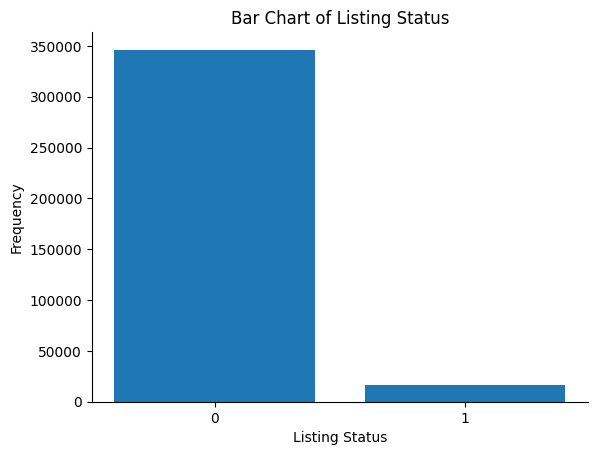

In [228]:
plt.bar(
    df_clean["unlisted"].value_counts().index,
    df_clean["unlisted"].value_counts().values,
)
plt.grid(False)
plt.title("Bar Chart of Listing Status")
plt.xlabel("Listing Status")
plt.ylabel("Frequency")
plt.xticks(np.arange(0,2))
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

### Description

In [229]:
# Get size of description and order by biggest to smallest
df_clean["description"].apply(len).value_counts()

description
692    3911
683    3375
649    3365
661    3308
669    3192
       ... 
70        1
40        1
255       1
101       1
80        1
Name: count, Length: 748, dtype: int64

In [230]:
# Get Description word count and order by biggest to smallest
df_clean["description_word_count"] = df_clean["description"].apply(
    lambda x: len(str(x).split(" "))
)
df_clean["description_word_count"].value_counts()

description_word_count
97     16509
91     15288
93     14980
95     14847
98     13679
       ...  
129        3
132        2
128        2
144        1
136        1
Name: count, Length: 131, dtype: int64

In [231]:
df_clean[df_clean["description_word_count"] == 3]["description"]

42397     license number exempt
42398     license number exempt
42399     license number exempt
42400     license number exempt
42401     license number exempt
                  ...          
362707    license number exempt
362708    license number exempt
362709    license number exempt
362710    license number exempt
362711    license number exempt
Name: description, Length: 446, dtype: object

In [232]:
df_clean["description_word_count"].describe()

count    363012.000000
mean         80.725037
std          24.487138
min           2.000000
25%          70.000000
50%          90.000000
75%          97.000000
max         160.000000
Name: description_word_count, dtype: float64

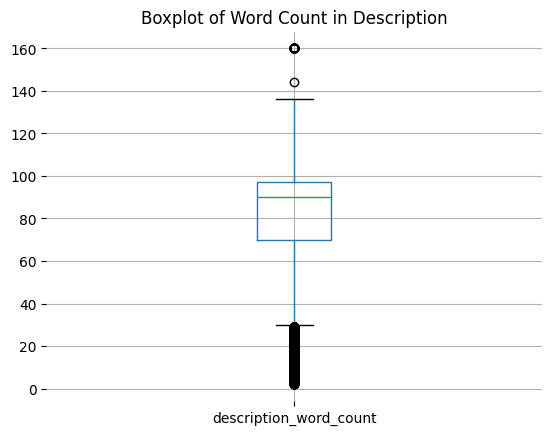

In [233]:
df_clean.boxplot(column=["description_word_count"])
plt.title("Boxplot of Word Count in Description")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.show()

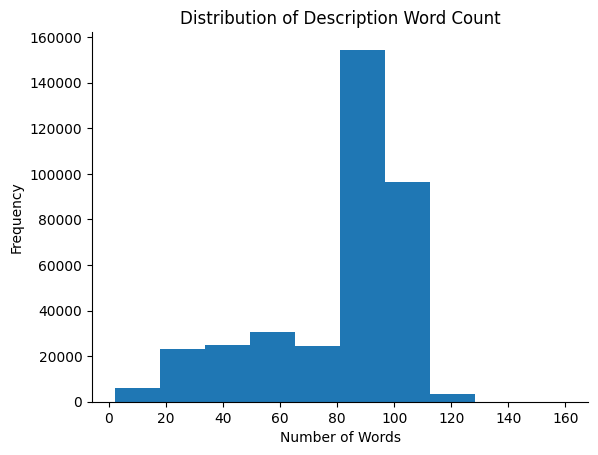

In [234]:
df_clean["description_word_count"].hist()
plt.grid(False)
plt.title("Distribution of Description Word Count")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

> These plots give us visually the information we already had on the previous cell with the `.describe()` method.

##### Most Frequent Words in Description

In [235]:
all_words = " ".join(df_clean["description"].str.lower()).split()

freq = pd.Series(all_words).value_counts()

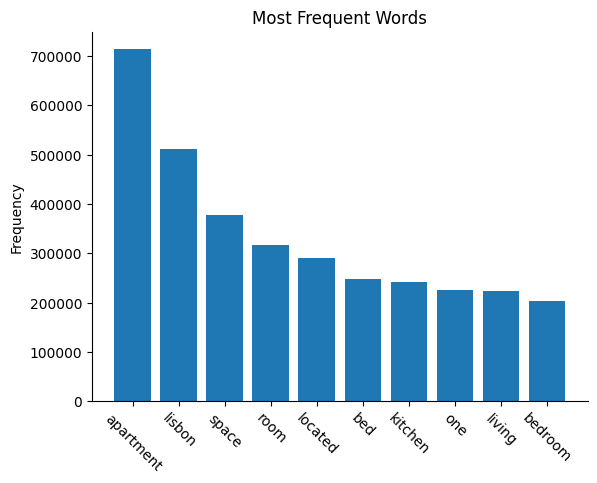

In [236]:
x_labels = freq.index[0:10]
values = freq[:10]
plt.bar(x_labels, values)
plt.xticks(x_labels, rotation = -45)
plt.ylabel("Frequency")
plt.title("Most Frequent Words")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

### Comments

To explore comments, we will first see how many empty comment rows we have.

In [237]:
df_clean["comments"].isna().sum()

0

In [238]:
comment_counts = df_clean.groupby("listing_id")["comments"].count()

# Sort the counts in descending order
sorted_comment_counts = comment_counts.sort_values(ascending=False)

# Display the top 10 indices with the most comments
top_10_indices = sorted_comment_counts.head(10)
top_10_indices

listing_id
265     887
3396    764
1147    678
4106    617
954     583
3729    578
1246    576
5833    570
5532    559
3085    552
Name: comments, dtype: int64

In [239]:
# get character count of comments
df_clean["comment_character_count"] = df_train_lm["comments"].apply(len)

df_clean["comment_character_count"].value_counts()

comment_character_count
12.0       2003
65.0          5
486.0         4
1422.0        4
222.0         4
           ... 
14469.0       1
1381.0        1
32676.0       1
567.0         1
41617.0       1
Name: count, Length: 3884, dtype: int64

In [240]:
df_clean[df_clean["comment_character_count"] == 3]["comments"].value_counts()

Series([], Name: count, dtype: int64)

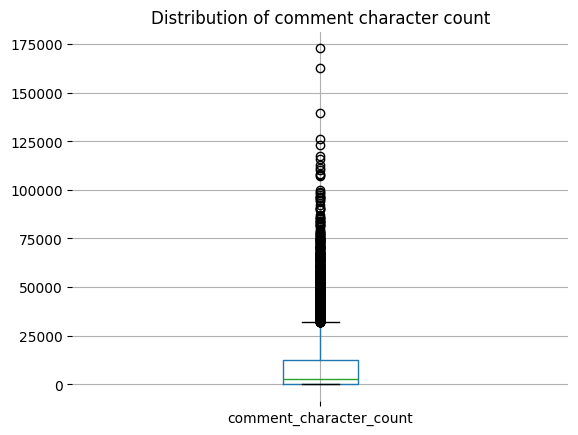

In [241]:
df_clean.boxplot(column=["comment_character_count"])
plt.title("Distribution of comment character count")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.show()

In [242]:
# get word count of comments
df_clean["comment_word_count"] = df_clean["comments"].apply(lambda x: len(str(x).split(" ")))

df_clean["comment_word_count"].value_counts()

comment_word_count
8      11622
9      11088
10     11084
7      11012
11     10985
       ...  
324        1
319        1
445        1
274        1
288        1
Name: count, Length: 342, dtype: int64

In [243]:
# Even 1-worded comments seem valid (apart from non-alphabetical ones, obviously)
df_clean[df_clean["comment_word_count"] == 1]["comments"][:]

1                good
13               nice
26                   
39                top
68          recommend
             ...     
362428      wonderful
362488        awesome
362732        perfect
362783    recommander
362993        perfect
Name: comments, Length: 3963, dtype: object

The preprocessing significantly reduced the number of 1 word comments existing. We only find 1. This is because our dataset is now merged.

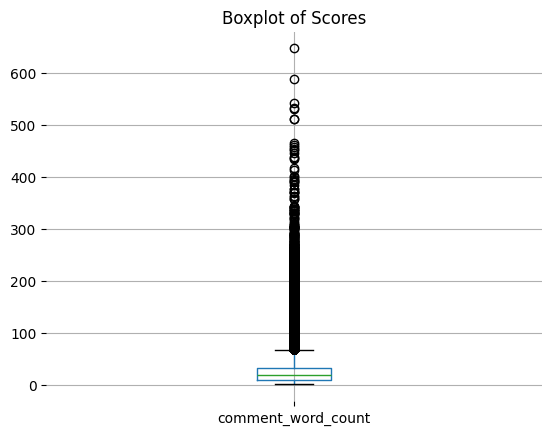

In [244]:
df_clean.boxplot(column=["comment_word_count"])
plt.title("Boxplot of Scores")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.show()

In [245]:
all_comment_words = " ".join(df_clean["comments"].str.lower()).split()

freq = pd.Series(all_comment_words).value_counts().sort_values(ascending=False)

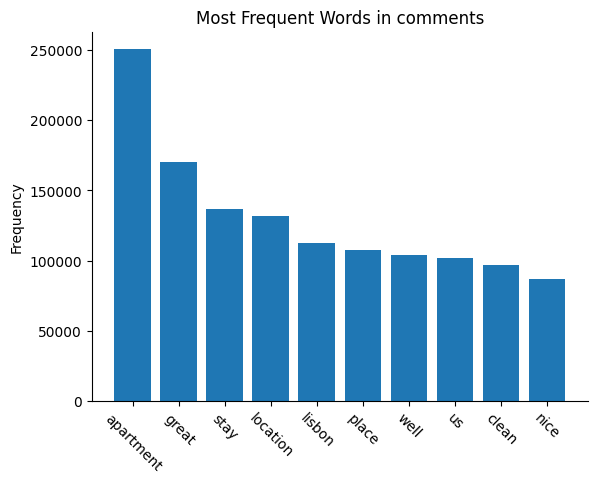

In [246]:
x_labels = freq.index[0:10]
values = freq[:10]
plt.bar(x_labels, values)
plt.xticks(x_labels, rotation = -45)
plt.ylabel("Frequency")
plt.title("Most Frequent Words in comments")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

In [247]:
# check for duplicated columns by 'listing_id' and 'comments', and show rows
duplicated_rows = df_clean[df_clean.duplicated(["listing_id", "comments"])]

duplicated_rows[["listing_id", "comments", "comment_word_count"]].sort_values("comment_word_count", ascending=False)[:10]

,listing_id,comments,comment_word_count
181978,3073,experience nuno something wish hope every airb...,259
143051,2422,europe apartment facilities well average jorge...,50
103983,1741,apartment much spacious thought pedro really e...,39
20831,378,gustavo rita abolutely fantastic hosts went wa...,38
334567,5769,great time staying hugo apartment exploring li...,38
200651,3409,great place hosts easy communicate accommodati...,35
188560,3198,rita miguel apartment one best locations city ...,33
113343,1928,great stay marta apartment clean tidy super he...,19
322895,5603,stay isabel great location amazing apartment r...,18
217664,3683,magnificent apartment splendid sea view isabel...,17


With preprocessing, we got rid of duplicates.

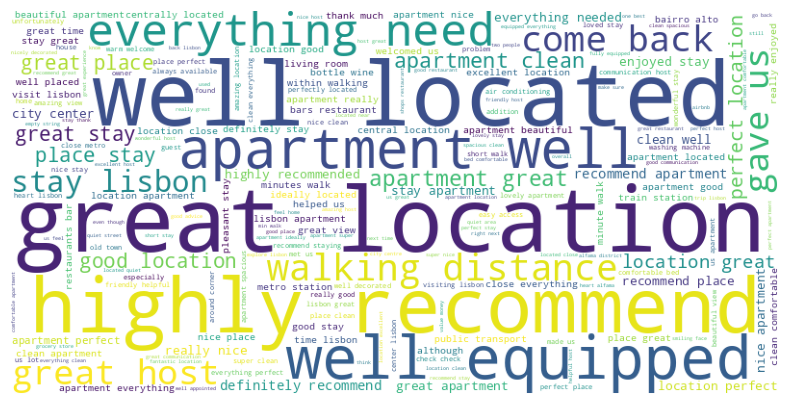

In [248]:
# Joining all the comments into a single string
all_reviews = " ".join(df_clean["comments"])

# Create WordCloud object
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(all_reviews)

# Plotting the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud)
plt.axis("off")
plt.show();

### Host_about

In [249]:
# Get character size of host_about
df_clean["host_about_character_count"] = df_clean["host_about"].apply(len)

df_clean["host_about_character_count"].value_counts()

host_about_character_count
12      5768
495     4037
314     3959
155     3721
452     3401
        ... 
1230       1
467        1
545        1
430        1
839        1
Name: count, Length: 679, dtype: int64

In [250]:
df_clean[df_clean["host_about_character_count"] == 6]["host_about"]

1698      suites
1699      suites
1700      suites
1701      suites
1702      suites
           ...  
313146    morena
313147    morena
313148    morena
313149    morena
313150    morena
Name: host_about, Length: 788, dtype: object

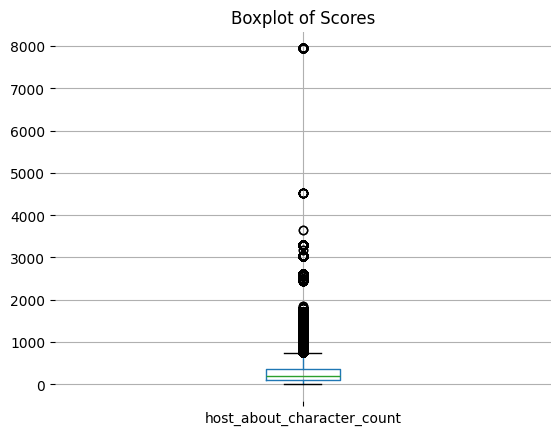

In [251]:
df_clean.boxplot(column=["host_about_character_count"])
plt.title("Boxplot of Scores")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.show()

We decided not to show a bar plot of the `host_about_character_count` as there are many outliers (as seen above) and it would make the plot unreadable.

In [252]:
df_clean["host_about_word_count"] = df_clean["host_about"].apply(lambda x: len(str(x).split(" ")))

df_clean["host_about_word_count"].value_counts()

host_about_word_count
2      12544
20      9801
5       9270
21      8552
67      8478
       ...  
103        2
162        1
125        1
104        1
110        1
Name: count, Length: 174, dtype: int64

In [253]:
# I think it's ok to say even from 1-worded host_about, it's still valid (apart from non-alphabetical ones, obviously)
df_clean[df_clean["host_about_word_count"] == 1]["host_about"]

1698             suites
1699             suites
1700             suites
1701             suites
1702             suites
              ...      
360385    perfectionist
360386    perfectionist
360387    perfectionist
360388    perfectionist
360389    perfectionist
Name: host_about, Length: 3906, dtype: object

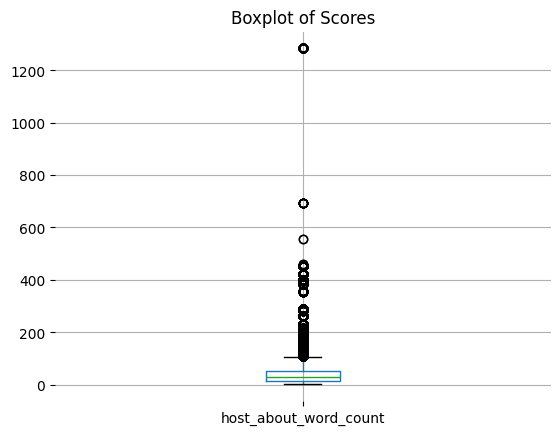

In [254]:
df_clean.boxplot(column=["host_about_word_count"])
plt.title("Boxplot of Scores")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.gca().spines["bottom"].set_visible(False)
plt.gca().spines["left"].set_visible(False)
plt.show()

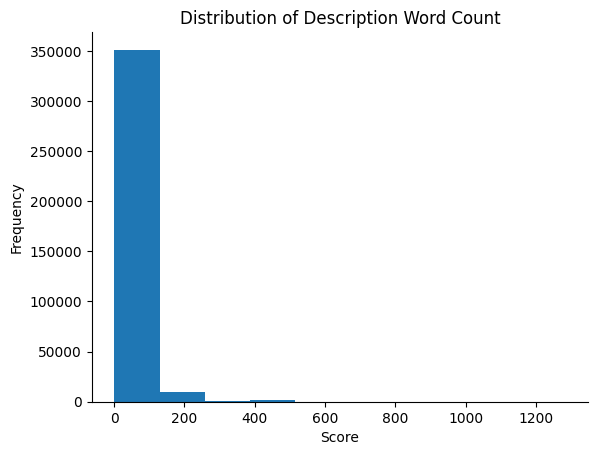

In [255]:
df_clean["host_about_word_count"].hist()
plt.grid(False)
plt.title("Distribution of Description Word Count")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

In [256]:
all_words = " ".join(df_clean["host_about"].str.lower()).split()

freq = pd.Series(all_words).value_counts()

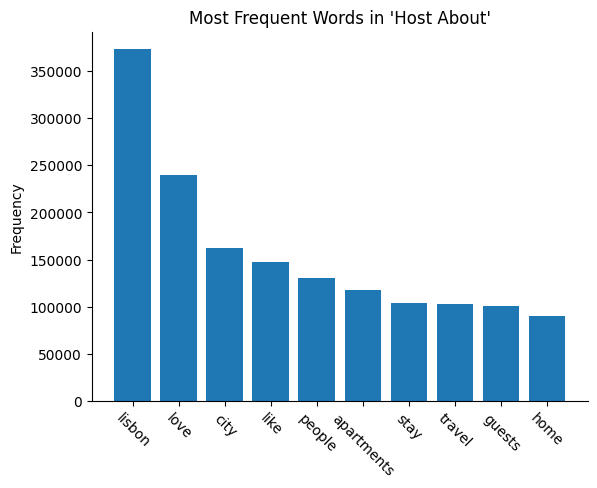

In [257]:
x_labels = freq.index[0:10]
values = freq[:10]
plt.bar(x_labels, values)
plt.xticks(x_labels, rotation = -45)
plt.ylabel("Frequency")
plt.title("Most Frequent Words in 'Host About'")
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.show()

Checking for duplicated `host_about` descriptions are unnecessary as hosts may have more than 1 listing.

# Feature Engineering

### Train-Test Split for **Lemmatized** data

##### **Note**: Although the train-test split is usually the first thing to be done, in our case we did not apply any methods to the data that would lead to data leakage. Therefore, it is fine to apply the train_test_split after the rest of the data preprocessing

In [258]:
df_train_lm = pd.read_csv("train_clean_merged_lm.csv")

In [259]:
X_data = df_train_lm.drop(columns=["unlisted"])
y_data = df_train_lm["unlisted"]
df_train, df_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, stratify=y_data, random_state=42)

In [260]:
df_train["unlisted"] = y_train
df_test["unlisted"] = y_test

In [261]:
# check proportion of unlisted after spliting
df_train["unlisted"].value_counts(normalize=True)

unlisted
0    0.726732
1    0.273268
Name: proportion, dtype: float64

Proportion holds after splitting.

In [262]:
df_train.to_csv("df_train_split_lm.csv", index = False)
df_test.to_csv("df_test_split_lm.csv", index = False)

### Train-Test Split for **Stemmed** data

In [263]:
df_train_stm = pd.read_csv("train_clean_merged_stm.csv")

In [264]:
X_data = df_train_stm.drop(columns=["unlisted"])
y_data = df_train_stm["unlisted"]
df_train, df_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, stratify=y_data, random_state=42)

In [265]:
df_train["unlisted"] = y_train
df_test["unlisted"] = y_test

In [266]:
# check proportion of unlisted after spliting
df_train["unlisted"].value_counts(normalize=True)

unlisted
0    0.726732
1    0.273268
Name: proportion, dtype: float64

Proportion holds after splitting.

In [267]:
df_train.to_csv("df_train_split_stm.csv", index = False)
df_test.to_csv("df_test_split_stm.csv", index = False)

### Word2Vec Implementation (with lemmatized data)

#### Corpus definition

In [268]:
df_train = pd.read_csv("train_clean_merged_lm.csv")

In [269]:
def sentence_to_wordlist(raw):
    words = word_tokenize(raw)  # Tokenize words in each sentence
    return words

# Tokenize each comment into sentences, then words, and flatten into a single list
corpus = [sentence_to_wordlist(sentence) for comment in df_train['comments'] for sentence in sent_tokenize(comment)]

In [270]:
loss_list = []
loss_list.append(0)

logging.basicConfig(format='%(asctime)s : %(levelname)s : %(message)s', level=logging.INFO)

class Callback(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0

        def on_epoch_end(self, model):
            loss = model.get_latest_training_loss()
            now_loss = loss - loss_list[-1]
            loss_list.append(loss)
            print(f"Loss after epoch {self.epoch}: {now_loss}")
            self.epoch = self.epoch + 1

In [271]:
w2v = Word2Vec(corpus, min_count = 10, vector_size = 400, sg = 1, compute_loss = True, workers = 4, seed = 42, epochs = 500,  callbacks=[Callback()]) 

2025-05-16 19:50:42,846 : INFO : collecting all words and their counts
2025-05-16 19:50:42,847 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2025-05-16 19:50:45,315 : INFO : collected 66073 word types from a corpus of 9496159 raw words and 6248 sentences
2025-05-16 19:50:45,339 : INFO : Creating a fresh vocabulary
2025-05-16 19:50:45,425 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=10 retains 11711 unique words (17.72% of original 66073, drops 54362)', 'datetime': '2025-05-16T19:50:45.425333', 'gensim': '4.3.2', 'python': '3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.19045-SP0', 'event': 'prepare_vocab'}
2025-05-16 19:50:45,426 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=10 leaves 9392172 word corpus (98.90% of original 9496159, drops 103987)', 'datetime': '2025-05-16T19:50:45.426338', 'gensim': '4.3.2', 'python': '3.11.4 (tags/v3.11.4:d2340ef, Jun  7 202

In [ ]:
# Saving the model
with tempfile.NamedTemporaryFile(prefix='gensim-model-', delete=False) as tmp:
    temporary_filepath = tmp.name
    w2v.save(temporary_filepath)

2025-05-17 01:32:11,151 : INFO : Word2Vec lifecycle event {'fname_or_handle': 'C:\\Users\\andre\\AppData\\Local\\Temp\\gensim-model-ob7xia55', 'separately': 'None', 'sep_limit': 10485760, 'ignore': frozenset(), 'datetime': '2025-05-17T01:32:11.151128', 'gensim': '4.3.2', 'python': '3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.19045-SP0', 'event': 'saving'}
2025-05-17 01:32:11,155 : INFO : not storing attribute cum_table
2025-05-17 01:32:11,299 : INFO : saved C:\Users\andre\AppData\Local\Temp\gensim-model-ob7xia55


In [273]:
# Load model
w2v = gensim.models.Word2Vec.load('C:\\Users\\andre\\OneDrive\\Documentos\\Nova IMS\\1º ano\\2º Semestre\\Text Mining\\Project\\Repos\\NLP_AirBnB-Listings\\data\\w2v_model_final')

2025-05-17 02:03:57,364 : INFO : loading Word2Vec object from C:\Users\andre\OneDrive\Documentos\Nova IMS\1º ano\2º Semestre\Text Mining\Project\Repos\NLP_AirBnB-Listings\data\w2v_model_final
2025-05-17 02:03:58,002 : INFO : loading wv recursively from C:\Users\andre\OneDrive\Documentos\Nova IMS\1º ano\2º Semestre\Text Mining\Project\Repos\NLP_AirBnB-Listings\data\w2v_model_final.wv.* with mmap=None
2025-05-17 02:03:58,004 : INFO : setting ignored attribute cum_table to None
2025-05-17 02:03:58,105 : INFO : Word2Vec lifecycle event {'fname': 'C:\\Users\\andre\\OneDrive\\Documentos\\Nova IMS\\1º ano\\2º Semestre\\Text Mining\\Project\\Repos\\NLP_AirBnB-Listings\\data\\w2v_model_final', 'datetime': '2025-05-17T02:03:58.105459', 'gensim': '4.3.2', 'python': '3.11.4 (tags/v3.11.4:d2340ef, Jun  7 2023, 05:45:37) [MSC v.1934 64 bit (AMD64)]', 'platform': 'Windows-10-10.0.19045-SP0', 'event': 'loaded'}


In [274]:
# Auxiliary function

def reduce_dimensions(model):
    num_dimensions = 2  # final num dimensions (2D, 3D, etc)

    # extract the words & their vectors, as numpy arrays
    vectors = np.asarray(model.wv.vectors)
    labels = np.asarray(model.wv.index_to_key)  # fixed-width numpy strings

   # # Convert numpy strings to standard Python strings (maybe not needed)
    #labels = [str(label) for label in labels]

    # reduce using t-SNE
    tsne = TSNE(n_components=num_dimensions, random_state=42)
    vectors = tsne.fit_transform(vectors)

    x_vals = [v[0] for v in vectors]
    y_vals = [v[1] for v in vectors]
    return x_vals, y_vals, labels

In [275]:
# Auxiliary function

def plot_with_plotly(x_vals, y_vals, labels, plot_in_notebook=True):
    from plotly.offline import init_notebook_mode, iplot, plot
    import plotly.graph_objs as go

    # Define the trace
    trace = go.Scatter(x=x_vals, y=y_vals, mode='markers', text=labels, hoverinfo='text')
    data = [trace]
    
    # Define the layout
    layout = go.Layout(
        title='Hover over points to see labels',
        xaxis=dict(title='X Axis Label'),
        yaxis=dict(title='Y Axis Label'),
        hovermode='closest'  # Ensures the hover is for the closest point
    )

    # Create a figure with data and layout
    fig = go.Figure(data=data, layout=layout)

    # Plot in notebook or create HTML file
    if plot_in_notebook:
        init_notebook_mode(connected=True)
        iplot(fig)
    else:
        plot(fig, filename='plot.html')  # Outputs an HTML file with the plot

In [276]:
x_vals, y_vals, labels = reduce_dimensions(w2v)

In [277]:
plot_with_plotly(x_vals, y_vals, labels, plot_in_notebook=True)

### Implementing Transformer: Roberta - `j-hartmann/emotion-english-roberta-large`: https://huggingface.co/j-hartmann/emotion-english-roberta-large

**Note**: Since this engineering method is only implemented to guarantee the 4 implementations necessary for the project requirements, we will work with the whole dataset (without train_test split). We will not use this method in later stages.

In [ ]:
# Using lemmatized dataset
df_train = pd.read_csv("train_clean_merged_lm.csv")
df_test = pd.read_csv("test_clean_merged_lm.csv")

In [ ]:
notebook_login()

In [281]:
def get_embeddings_roberta(dataframe:pd.DataFrame, model_name:str="j-hartmann/emotion-english-roberta-large", max_length:int=512):
    
    copy_df = dataframe.copy()
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModel.from_pretrained(model_name).to(device)

    def get_actual_embeddings(text,model_obj, tokenizer_obj, max_length=512):

        inputs = tokenizer_obj(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length).to(device)
        outputs = model_obj(**inputs)
        mean_embeddings = outputs.last_hidden_state.mean(dim=1).detach().cpu().numpy()
        
        return mean_embeddings
    
    mean_embeddings_dict = {}
    
    # use tqdm to know how much time left
    for row_index, row in tqdm(copy_df.iterrows(), total=len(copy_df)):
        listing_id = row["listing_id"]
        comment = str(row["comments"])
        unlisted = row["unlisted"]
        mean_embeddings = get_actual_embeddings(comment, model, tokenizer, max_length)
        mean_embeddings_dict[listing_id] = {"embeddings":mean_embeddings, "target":unlisted}
    # save the embeddings on a column

    return mean_embeddings_dict

In [ ]:
# train set
train_embeddings_roberta = get_embeddings_roberta(df_train, model_name="j-hartmann/emotion-english-roberta-large", max_length=512)

# test set
test_embeddings_roberta = get_embeddings_roberta(df_test, model_name="j-hartmann/emotion-english-roberta-large", max_length=512)


# prepare embeddings for models (TRAINING SET)
train_embeddings_roberta_models = np.array([train_embeddings_roberta[key]["embeddings"] for key in train_embeddings_roberta.keys()])
train_embeddings_roberta_models = train_embeddings_roberta_models.reshape(train_embeddings_roberta_models.shape[0], train_embeddings_roberta_models.shape[2])

# target for sklearn (TRAINING SET)
target_embeddings_roberta_models = np.array([train_embeddings_roberta[key]["target"] for key in train_embeddings_roberta.keys()])
target_embeddings_roberta_models = target_embeddings_roberta_models.reshape(-1,1)

In [ ]:
# They must have the same shape
train_embeddings_roberta_models.shape, target_embeddings_roberta_models.shape

In [ ]:
# Prepare training targets (from TRAINING data)
train_targets = np.array([train_embeddings_roberta[key]["target"] for key in train_embeddings_roberta.keys()])

In [ ]:
# Prepare test data for evaluation
test_embeddings_roberta_models = np.array([test_embeddings_roberta[key]["embeddings"] for key in test_embeddings_roberta.keys()])
test_embeddings_roberta_models = test_embeddings_roberta_models.reshape(test_embeddings_roberta_models.shape[0], test_embeddings_roberta_models.shape[2])

##### Performing one experiment only with this transformer

In [ ]:
# Fit the model
lr_roberta_model = LogisticRegression(class_weight="balanced", random_state=42, n_jobs=-1)
lr_roberta_model.fit(train_embeddings_roberta_models, train_targets)

In [ ]:
# Prepare test data for evaluation
test_embeddings_roberta_models = np.array([test_embeddings_roberta[key]["embeddings"] for key in test_embeddings_roberta.keys()])
test_embeddings_roberta_models = test_embeddings_roberta_models.reshape(test_embeddings_roberta_models.shape[0], test_embeddings_roberta_models.shape[2])

In [ ]:
# Get predictions
lr_roberta_model_predictions = lr_roberta_model.predict(test_embeddings_roberta_models)

In [ ]:
# Extract test targets for evaluation
test_targets = np.array([test_embeddings_roberta[key]["target"] for key in test_embeddings_roberta.keys()])

In [ ]:
# Classification report
lr_robert_model_report = classification_report(test_targets, lr_roberta_model_predictions, target_names=["listed", "unlisted"])

print("LOGISTIC REGRESSION WITH EMBEDDINGS (MEAN BERT) REPORT\n \n")

print(lr_robert_model_report)

plot_conf_matrix(test_targets, lr_roberta_model_predictions, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized Roberta Logistic Regression Confusion Matrix")

### From this part onwards, as the project requirements expect us to experiment different combinations of preprocessing, engineering, and classification methods, the notebook will branch out into 3 parts.

> ##### Part 1: Lemmatization + TF-IDF + Classification (All models)
> ##### Part 2: Lemmatization + GloVe + Classification (All models)
> ##### Part 3: Stemming + Transformer (BERT) + Classification (All models)
> ##### Part 4: Evaluation: Choose best model out of all combinations based on F1 score, and apply to test set for predictions.

# Part 1: Lemmatization + TF-IDF + Classification (All models)

# TF-IDF

In [ ]:
df_train = pd.read_csv("df_train_split_lm.csv")
df_test = pd.read_csv("df_test_split_lm.csv")

In [ ]:
tf_idf = TfidfVectorizer(max_features=15000,smooth_idf=True, stop_words="english", sublinear_tf=True)

In [ ]:
X_data_train, y_data_train = tf_idf.fit_transform(df_train["comments"]), df_train["unlisted"]

X_data_test, y_data_test = tf_idf.transform(df_test["comments"]), df_test["unlisted"]

In [ ]:
X_data_train.shape, X_data_test.shape, y_data_train.shape, y_data_test.shape

# Models

In [ ]:
# Logistic Regression

lr = LogisticRegression(class_weight="balanced", random_state=42, n_jobs=-1)

lr.fit(X_data_train, y_data_train)

predictions_lr = lr.predict(X_data_test)

lr_classif_report = classification_report(y_data_test, predictions_lr)


print("\n \n Lemmatized TF-IDF Logistic Regression Classifier \n \n")

print(lr_classif_report)

print("\n \n")

plot_conf_matrix(y_data_test, predictions_lr, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized TF-IDF Logistic Regression Classifier")

In [ ]:
# K-Nearest Neighbors

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn.fit(X_data_train, y_data_train)

predictions_knn = knn.predict(X_data_test)

knn_classif_report = classification_report(y_data_test, predictions_knn)


print("\n \n Lemmatized TF-IDF KNN Classifier \n \n")

print(knn_classif_report)

print("\n \n")

plot_conf_matrix(y_data_test, predictions_knn, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized TF-IDF KNN Classifier")

In [ ]:
# Stochastic Gradient Descent

sgd = SGDClassifier(loss="hinge", penalty="l2", max_iter=1000, class_weight="balanced",\
     random_state=42, fit_intercept=False, tol=0.001, early_stopping=True, validation_fraction=0.1, \
        n_iter_no_change=5, n_jobs=-1, verbose=1, shuffle=True, learning_rate="adaptive", eta0=0.000001)

sgd.fit(X_data_train, y_data_train)

predictions_sgd = sgd.predict(X_data_test)

sgd_classif_report = classification_report(y_data_test, predictions_sgd)

In [ ]:
print("\n \n Lemmatized TF-IDF SGD Classifier \n \n")

print(sgd_classif_report)

print("\n \n")

plot_conf_matrix(y_data_test, predictions_sgd, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized TF-IDF SGD Classifier")

In [ ]:
# Multi-Layer Perceptron (MLP)

mlp = MLPClassifier(solver='adam', hidden_layer_sizes=(2,2), activation='logistic', random_state=42)

mlp.fit(X_data_train, y_data_train)

predictions_mlp = mlp.predict(X_data_test)

mlp_classif_report = classification_report(y_data_test, predictions_mlp)


print("\n \n Lemmatized TF-IDF MLP Classifier \n \n")

print(mlp_classif_report)

print("\n \n")

plot_conf_matrix(y_data_test, predictions_mlp, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized TF-IDF MLP Classifier")

#### Other Advanced Models - Random Forest and HistGradientBoosting

In [ ]:
# Random Forest

rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced", verbose=1)

rf_classifier.fit(X_data_train, y_data_train)

predictions_rf = rf_classifier.predict(X_data_test)

rf_classif_report = classification_report(y_data_test, predictions_rf)


print("\n \n Lemmatized TF-IDF Random Forest Classifier \n \n")

print(rf_classif_report)

print("\n \n")

plot_conf_matrix(y_data_test, predictions_rf, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized TF-IDF Random Forest Classifier")

In [ ]:
# HistGradientBoosting

hist_grad_boost = HistGradientBoostingClassifier(random_state=42, verbose=1)

hist_grad_boost.fit(X_data_train.toarray(), y_data_train)

predictions_histgradboost = hist_grad_boost.predict(X_data_test.toarray())

histgradboost_classif_report = classification_report(y_data_test, predictions_histgradboost)

In [ ]:
print("\n \n Lemmatized TF-IDF HistGradientBoosting Classifier \n \n")

print(histgradboost_classif_report)

print("\n \n")

plot_conf_matrix(y_data_test, predictions_histgradboost, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized TF-IDF Random Forest Classifier")

# Part 2: Lemmatization + GloVe + Classification (All models)

# GloVe

In [ ]:
df_train = pd.read_csv("df_train_split_lm.csv")
df_test = pd.read_csv("df_test_split_lm.csv")

In [ ]:
glove = vocab.GloVe(name='840B', dim=300)
print(f'Loaded {len(glove.itos)} words')

In [ ]:
def from_sentence_to_vec_840B(sentence_to_vectorize):
    sentence_vec = []
    for word in sentence_to_vectorize:
        try:
            word_vec = glove.get_vecs_by_tokens(word, lower_case_backup=True)
            sentence_vec.append(word_vec)
        except KeyError:
            pass
    sentence_mean = np.mean(sentence_vec, axis=0)
    return sentence_mean

In [ ]:
train_comments_list = df_train["comments"].tolist()
train_comments_list = [sentence.split() for sentence in train_comments_list]

test_comments_list = df_test["comments"].tolist()
test_comments_list = [sentence.split() for sentence in test_comments_list]

In [ ]:
sentence_vecs_train = []
sentence_vecs_test = []

# train
for i in tqdm(range(len(train_comments_list))):
    sentence_vec = from_sentence_to_vec_840B(train_comments_list[i])
    sentence_vecs_train.append(sentence_vec)

# test
for i in tqdm(range(len(test_comments_list))):
    sentence_vec = from_sentence_to_vec_840B(test_comments_list[i])
    sentence_vecs_test.append(sentence_vec)

In [ ]:
sentence_vecs_train = torch.tensor(sentence_vecs_train)
sentence_vecs_test = torch.tensor(sentence_vecs_test)

target_train = torch.tensor(df_train["unlisted"].tolist())
target_test = torch.tensor(df_test["unlisted"].tolist())

# Models

In [ ]:
# Logistic Regression

lr = LogisticRegression(class_weight="balanced", random_state=42, n_jobs=-1)

lr.fit(sentence_vecs_train, target_train)

predictions_lr = lr.predict(sentence_vecs_test)

lr_classif_report = classification_report(target_test, predictions_lr)


print("\n \n Lemmatized GloVe Logistic Regression Classifier \n \n")

print(lr_classif_report)

print("\n \n")

plot_conf_matrix(target_test, predictions_lr, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized GloVe Logistic Regression Classifier")


In [ ]:
# K-Nearest Neighbors

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn.fit(sentence_vecs_train, target_train)

predictions_knn = knn.predict(sentence_vecs_test)

knn_classif_report = classification_report(target_test, predictions_knn)


print("\n \n Lemmatized GloVe KNN Classifier \n \n")

print(knn_classif_report)

print("\n \n")

plot_conf_matrix(target_test, predictions_knn, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized GloVe KNN Classifier")

In [ ]:
# Stochastic Gradient Descent

sgd = SGDClassifier(loss="hinge", penalty="l2", max_iter=1000, class_weight="balanced",\
     random_state=42, fit_intercept=False, tol=0.001, early_stopping=True, validation_fraction=0.1, \
        n_iter_no_change=5, n_jobs=-1, verbose=1, shuffle=True, learning_rate="adaptive", eta0=0.000001)

sgd.fit(sentence_vecs_train, target_train)

predictions_sgd = sgd.predict(sentence_vecs_test)

sgd_classif_report = classification_report(target_test, predictions_sgd)


print("\n \n Lemmatized GloVe SGD Classifier \n \n")

print(sgd_classif_report)

print("\n \n")

plot_conf_matrix(target_test, predictions_sgd, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized GloVe SGD Classifier")

In [ ]:
# Multi-Layer Perceptron (MLP)

mlp = MLPClassifier(solver='adam', hidden_layer_sizes=(2,2), activation='logistic', random_state=42)

mlp.fit(sentence_vecs_train, target_train)

predictions_mlp = mlp.predict(sentence_vecs_test)

mlp_classif_report = classification_report(target_test, predictions_mlp)


print("\n \n Lemmatized GloVe MLP Classifier \n \n")

print(mlp_classif_report)

print("\n \n")

plot_conf_matrix(target_test, predictions_mlp, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized GloVe MLP Classifier")

#### Other Advanced Models - Random Forest and HistGradientBoosting

In [ ]:
# Random Forest

rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced", verbose=1)

rf_classifier.fit(sentence_vecs_train, target_train)

predictions_rf = rf_classifier.predict(sentence_vecs_test)

rf_classif_report = classification_report(target_test, predictions_rf)



print("\n \n Lemmatized GloVe Random Forest Classifier \n \n")

print(rf_classif_report)

print("\n \n")

plot_conf_matrix(target_test, predictions_rf, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized GloVe Random Forest Classifier")

In [ ]:
# HistGradientBoosting

hist_grad_boost = HistGradientBoostingClassifier(random_state=42, verbose=1)

hist_grad_boost.fit(sentence_vecs_train, target_train)

predictions_histgradboost = hist_grad_boost.predict(sentence_vecs_test)

histgradboost_classif_report = classification_report(target_test, predictions_histgradboost)


print("\n \n Lemmatized GloVe HistGradientBoosting Classifier \n \n")

plot_conf_matrix(target_test, predictions_histgradboost, labels=["Not Unlisted", "Unlisted"], plot_name="Lemmatized GloVe HistGradientBoosting Classifier")

In [ ]:
# Classification report
print("\n \n")
print(histgradboost_classif_report)

# Part 3 - Stemming + BERT + Classification (All models)

https://huggingface.co/google-bert/bert-base-uncased

In [ ]:
df_train = pd.read_csv("df_train_split_stm.csv")
df_test = pd.read_csv("df_test_split_stm.csv")

## BERT

In [ ]:
notebook_login()

In [ ]:
def get_embeddings_bert(dataframe:pd.DataFrame, model_name:str="google-bert/bert-base-uncased", max_length:int=512):
    copy_df = dataframe.copy()
    
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    tokenizer = AutoTokenizer.from_pretrained(model_name)

    model = AutoModel.from_pretrained(model_name).to(device)

    def get_actual_embeddings(text,model_obj, tokenizer_obj, max_length=512):

        inputs = tokenizer_obj(text, return_tensors="pt", truncation=True, padding=True, max_length=max_length).to(device)
        outputs = model_obj(**inputs)
        cls_embeddings = outputs.last_hidden_state[:,0,:].detach().cpu().numpy()
        mean_embeddings = outputs.last_hidden_state.mean(dim=1).detach().cpu().numpy()

        return cls_embeddings, mean_embeddings
    
    cls_embeddings_dict = {}
    mean_embeddings_dict = {}

    # use tqdm to know how much time left
    for row_index, row in tqdm(copy_df.iterrows(), total=len(copy_df)):
        listing_id = row["listing_id"]
        comment = str(row["comments"])
        unlisted = row["unlisted"]

        cls_embeddings, mean_embeddings = get_actual_embeddings(comment, model, tokenizer, max_length)
        cls_embeddings_dict[listing_id] = {"embeddings":cls_embeddings, "target":unlisted}
        mean_embeddings_dict[listing_id] = {"embeddings":mean_embeddings, "target":unlisted}
        
    # save the embeddings on a column

    return cls_embeddings_dict, mean_embeddings_dict

In [ ]:
cls_train_embeddings, mean_train_embeddings = get_embeddings_bert(df_train, model_name="google-bert/bert-base-uncased", max_length=512)

In [ ]:
cls_test_embeddings, mean_test_embeddings = get_embeddings_bert(df_test, model_name="google-bert/bert-base-uncased", max_length=512)

In [ ]:
# prepare embeddings for models - TRAIN
cls_train_embeddings = np.array([cls_train_embeddings[key]["embeddings"] for key in cls_train_embeddings.keys()])
cls_train_embeddings = cls_train_embeddings.reshape(cls_train_embeddings.shape[0], mean_train_embeddings.shape[2])

# target
cls_train_embeddings_target = np.array([cls_train_embeddings[key]["target"] for key in cls_train_embeddings.keys()])
cls_train_embeddings_target = cls_train_embeddings_target.reshape(-1,1)

In [ ]:
# prepare embeddings for models - TEST
cls_test_embeddings = np.array([cls_test_embeddings[key]["embeddings"] for key in cls_test_embeddings.keys()])
cls_test_embeddings = cls_test_embeddings.reshape(cls_test_embeddings.shape[0], mean_train_embeddings.shape[2])

# target
cls_test_embeddings_target = np.array([cls_test_embeddings[key]["target"] for key in cls_train_embeddings.keys()])
cls_test_embeddings_target = cls_test_embeddings_target.reshape(-1,1)

In [ ]:
cls_train_embeddings.shape, cls_train_embeddings_target.shape

In [ ]:
cls_test_embeddings.shape, cls_test_embeddings_target.shape

# Models

In [ ]:
# Logistic Regression

lr = LogisticRegression(class_weight="balanced", random_state=42, n_jobs=-1)

lr.fit(cls_train_embeddings, cls_train_embeddings_target)

predictions_lr = lr.predict(cls_test_embeddings)

lr_classif_report = classification_report(cls_test_embeddings_target, predictions_lr)


print("\n \n Stemmed BERT Logistic Regression Classifier \n \n")

print(lr_classif_report)

print("\n \n")

plot_conf_matrix(cls_test_embeddings_target, predictions_lr, labels=["Not Unlisted", "Unlisted"], plot_name="Stemmed BERT Logistic Regression Classifier")


In [ ]:
# K-Nearest Neighbors

knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

knn.fit(cls_train_embeddings, cls_train_embeddings_target)

predictions_knn = knn.predict(cls_test_embeddings)

knn_classif_report = classification_report(cls_test_embeddings_target, predictions_knn)


print("\n \n Stemmed BERT KNN Classifier \n \n")

print(knn_classif_report)

print("\n \n")

plot_conf_matrix(cls_test_embeddings_target, predictions_knn, labels=["Not Unlisted", "Unlisted"], plot_name="Stemmed BERT KNN Classifier")

In [ ]:
# Stochastic Gradient Descent

sgd = SGDClassifier(loss="hinge", penalty="l2", max_iter=1000, class_weight="balanced",\
     random_state=42, fit_intercept=False, tol=0.001, early_stopping=True, validation_fraction=0.1, \
        n_iter_no_change=5, n_jobs=-1, verbose=1, shuffle=True, learning_rate="adaptive", eta0=0.000001)

sgd.fit(cls_train_embeddings, cls_train_embeddings_target)

predictions_sgd = sgd.predict(cls_test_embeddings)

sgd_classif_report = classification_report(cls_test_embeddings_target, predictions_sgd)


print("\n \n Stemmed BERT SGD Classifier \n \n")

print(sgd_classif_report)

print("\n \n")

plot_conf_matrix(cls_test_embeddings_target, predictions_sgd, labels=["Not Unlisted", "Unlisted"], plot_name="Stemmed BERT SGD Classifier")

In [ ]:
# Multi-Layer Perceptron (MLP)

mlp = MLPClassifier(solver='adam', hidden_layer_sizes=(2,2), activation='logistic', random_state=42)

mlp.fit(cls_train_embeddings, cls_train_embeddings_target)

predictions_mlp = mlp.predict(cls_test_embeddings)

mlp_classif_report = classification_report(cls_test_embeddings_target, predictions_mlp)


print("\n \n Stemmed BERT SGD Classifier \n \n")

print(mlp_classif_report)

print("\n \n")

plot_conf_matrix(cls_test_embeddings_target, predictions_mlp, labels=["Not Unlisted", "Unlisted"], plot_name="Stemmed BERT MLP Classifier")

#### Other Advanced Models - Random Forest and HistGradientBoosting

In [ ]:
# Random Forest

rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1, class_weight="balanced", verbose=1)

rf_classifier.fit(cls_train_embeddings, cls_train_embeddings_target)

predictions_rf = rf_classifier.predict(cls_test_embeddings)

rf_classif_report = classification_report(cls_test_embeddings_target, predictions_rf)


print("\n \n Stemmed BERT Random Forest Classifier \n \n")

print(rf_classif_report)

print("\n \n")

plot_conf_matrix(cls_test_embeddings_target, predictions_rf, labels=["Not Unlisted", "Unlisted"], plot_name="Stemmed BERT Random Forest Classifier")

In [ ]:
# HistGradientBoosting

hist_grad_boost = HistGradientBoostingClassifier(random_state=42, verbose=1)

hist_grad_boost.fit(cls_train_embeddings.toarray(), cls_train_embeddings_target)

predictions_histgradboost = hist_grad_boost.predict(cls_test_embeddings.toarray())

histgradboost_classif_report = classification_report(cls_test_embeddings_target, predictions_histgradboost)


print("\n \n Stemmed BERT HistGradientBoosting Classifier \n \n")

print(histgradboost_classif_report)

print("\n \n")

plot_conf_matrix(cls_test_embeddings_target, predictions_histgradboost, labels=["Not Unlisted", "Unlisted"], plot_name="Stemmed BERTF Random Forest Classifier")

# Part 4: Prediction on test set with best model:  Lemmatized TF-IDF MLP Classifier

In [ ]:
df_test = pd.read_csv("test_clean_merged.csv")

In [ ]:
# Lemmatizing
updates = lemmatization(df_test["comments"])

update_df(df_test, updates)

In [ ]:
# Applying TF-IDF
test_data = tf_idf.transform(df_test["comments"])

In [ ]:
# Generating predictions
predictions_mlp = mlp.predict(test_data)

In [ ]:
predictions_mlp

In [ ]:
df_test.shape

In [ ]:
len(predictions_mlp)

In [ ]:
df_test.columns

In [ ]:
df_test["predicted"] = predictions_mlp

In [ ]:
df_test.head()

In [ ]:
columns = ["listing_id","predicted"]

In [ ]:
df_test = df_test[columns]

In [ ]:
df_test

In [ ]:
df_test.rename(columns={"listing_id":"id"}, inplace=True)

In [ ]:
df_test.to_csv("Predictions_15.csv", sep = ",", index = False)

In [ ]:
test = pd.read_csv("Predictions_15.csv")

In [ ]:
test